In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("TASK 1: FERTILE SITE RECOMMENDATION - OPTION 1")
print("TARGET: Nitrogen (Direct Prediction)")
print("="*80)

# ==============================================================================
# STEP 1: LOAD DATA
# ==============================================================================
print("\n1. LOADING DATA")
print("-" * 60)

# Load original data for target
df_original = pd.read_csv('csv/Bangalore_Monthly_Final_Corrected.csv')
print(f"Original data shape: {df_original.shape}")

# Load preprocessed features
X_train = pd.read_csv('csv/X_train.csv')
X_val = pd.read_csv('csv/X_val.csv')
X_test = pd.read_csv('csv/X_test.csv')

print(f"\nPreprocessed features loaded:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

TASK 1: FERTILE SITE RECOMMENDATION - OPTION 1
TARGET: Nitrogen (Direct Prediction)

1. LOADING DATA
------------------------------------------------------------
Original data shape: (23042, 26)

Preprocessed features loaded:
  X_train: (11397, 19)
  X_val: (3397, 19)
  X_test: (8248, 19)


In [2]:
# ==============================================================================
# STEP 2: CREATE TARGET VARIABLE (Nitrogen)
# ==============================================================================
print("\n2. CREATING TARGET VARIABLE: Nitrogen")
print("-" * 60)

# Parse date and create temporal features for splitting
df_original['date'] = pd.to_datetime(df_original['date'])
df_original['Year'] = df_original['date'].dt.year
df_original['Month_Actual'] = df_original['date'].dt.month

# Extract coordinates for sorting
import json
def extract_coordinates(geo_str):
    try:
        geo_dict = json.loads(geo_str)
        coords = geo_dict['coordinates']
        return coords[0], coords[1]
    except:
        return None, None

df_original['longitude'], df_original['latitude'] = zip(
    *df_original['.geo'].apply(extract_coordinates)
)

# Sort by date and location (MUST match preprocessing)
df_sorted = df_original.sort_values(['date', 'longitude', 'latitude']).reset_index(drop=True)

# Create same masks as preprocessing
train_mask = ((df_sorted['Year'] == 2021) | 
              ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] <= 6)))
val_mask = ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] >= 7))
test_mask = df_sorted['Year'] == 2023

# Extract Nitrogen as target (ORIGINAL, not log-transformed)
y_train = df_sorted.loc[train_mask, 'Nitrogen'].values
y_val = df_sorted.loc[val_mask, 'Nitrogen'].values
y_test = df_sorted.loc[test_mask, 'Nitrogen'].values

print(f"Target variable: Nitrogen (mg/kg)")
print(f"\nTarget statistics:")
print(f"  Train set: {len(y_train)} samples")
print(f"    Range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"    Mean: {y_train.mean():.2f} ± {y_train.std():.2f}")
print(f"\n  Validation set: {len(y_val)} samples")
print(f"    Range: [{y_val.min():.2f}, {y_val.max():.2f}]")
print(f"    Mean: {y_val.mean():.2f} ± {y_val.std():.2f}")
print(f"\n  Test set: {len(y_test)} samples")
print(f"    Range: [{y_test.min():.2f}, {y_test.max():.2f}]")
print(f"    Mean: {y_test.mean():.2f} ± {y_test.std():.2f}")


2. CREATING TARGET VARIABLE: Nitrogen
------------------------------------------------------------
Target variable: Nitrogen (mg/kg)

Target statistics:
  Train set: 11397 samples
    Range: [15.80, 50.10]
    Mean: 20.25 ± 3.59

  Validation set: 3397 samples
    Range: [15.80, 50.10]
    Mean: 20.22 ± 3.55

  Test set: 8248 samples
    Range: [15.80, 50.10]
    Mean: 20.24 ± 3.56


In [4]:
# ==============================================================================
# STEP 3: REMOVE NITROGEN_LOG FROM FEATURES (AVOID DATA LEAKAGE)
# ==============================================================================
print("\n3. REMOVING Nitrogen_log FROM FEATURES (No Data Leakage)")
print("-" * 60)

# Define features to KEEP (18 features - removed Nitrogen_log)
features_to_keep = [
    # Climate (4)
    'Rain_log', 'Temp', 'LST', 'SoilMoisture',
    
    # Vegetation (2)
    'NDVI', 'green_fraction_boxcox',
    
    # Soil (3) - REMOVED Nitrogen_log!
    'Clay', 'pH', 'BulkDensity',
    
    # Topography (2)
    'Elevation', 'Slope_log',
    
    # Pollution (3)
    'AOD_log', 'NO2_log', 'SO2',
    
    # Temporal (2)
    'Month_Sin', 'Month_Cos',
    
    # Spatial (2)
    'longitude', 'latitude'
]

print(f"Original features: {X_train.shape[1]}")
print(f"Features after removing Nitrogen_log: {len(features_to_keep)}")

# Verify Nitrogen_log is NOT in feature list
if 'Nitrogen_log' in features_to_keep:
    raise ValueError("ERROR: Nitrogen_log still in features! Data leakage!")
else:
    print("✓ Confirmed: Nitrogen_log removed - NO DATA LEAKAGE")

# Select only the features we want
X_train_clean = X_train[features_to_keep].copy()
X_val_clean = X_val[features_to_keep].copy()
X_test_clean = X_test[features_to_keep].copy()

print(f"\nFinal feature sets:")
print(f"  X_train: {X_train_clean.shape}")
print(f"  X_val: {X_val_clean.shape}")
print(f"  X_test: {X_test_clean.shape}")

# Print feature breakdown
print(f"\nFeature Categories:")
print(f"  Climate: Rain_log, Temp, LST, SoilMoisture")
print(f"  Vegetation: NDVI, green_fraction")
print(f"  Soil: Clay, pH, BulkDensity (NO Nitrogen!)")
print(f"  Topography: Elevation, Slope_log")
print(f"  Pollution: AOD_log, NO2_log, SO2")
print(f"  Temporal: Month_Sin, Month_Cos")
print(f"  Spatial: longitude, latitude")


3. REMOVING Nitrogen_log FROM FEATURES (No Data Leakage)
------------------------------------------------------------
Original features: 19
Features after removing Nitrogen_log: 18
✓ Confirmed: Nitrogen_log removed - NO DATA LEAKAGE

Final feature sets:
  X_train: (11397, 18)
  X_val: (3397, 18)
  X_test: (8248, 18)

Feature Categories:
  Climate: Rain_log, Temp, LST, SoilMoisture
  Vegetation: NDVI, green_fraction
  Soil: Clay, pH, BulkDensity (NO Nitrogen!)
  Topography: Elevation, Slope_log
  Pollution: AOD_log, NO2_log, SO2
  Temporal: Month_Sin, Month_Cos
  Spatial: longitude, latitude


In [5]:
# ==============================================================================
# STEP 4: TRAIN BASELINE RANDOM FOREST MODEL
# ==============================================================================
print("\n4. TRAINING RANDOM FOREST BASELINE MODEL")
print("-" * 60)

# Initialize model with good defaults
rf_model = RandomForestRegressor(
    n_estimators=200,        # More trees = better (diminishing returns after ~200)
    max_depth=20,            # Prevent overfitting
    min_samples_split=10,    # Require at least 10 samples to split
    min_samples_leaf=4,      # At least 4 samples per leaf
    max_features='sqrt',     # Use sqrt(n_features) for each split
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    verbose=0
)

print("Model hyperparameters:")
print(f"  n_estimators: {rf_model.n_estimators}")
print(f"  max_depth: {rf_model.max_depth}")
print(f"  min_samples_split: {rf_model.min_samples_split}")
print(f"  min_samples_leaf: {rf_model.min_samples_leaf}")
print(f"  max_features: {rf_model.max_features}")

print("\nTraining model...")
rf_model.fit(X_train_clean, y_train)
print("✓ Model trained successfully!")


4. TRAINING RANDOM FOREST BASELINE MODEL
------------------------------------------------------------
Model hyperparameters:
  n_estimators: 200
  max_depth: 20
  min_samples_split: 10
  min_samples_leaf: 4
  max_features: sqrt

Training model...
✓ Model trained successfully!


In [6]:
# ==============================================================================
# STEP 5: EVALUATE MODEL PERFORMANCE
# ==============================================================================
print("\n5. MODEL EVALUATION")
print("-" * 60)

# Predictions
y_train_pred = rf_model.predict(X_train_clean)
y_val_pred = rf_model.predict(X_val_clean)
y_test_pred = rf_model.predict(X_test_clean)

# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name} Set Metrics:")
    print(f"  MAE:  {mae:.3f} mg/kg")
    print(f"  RMSE: {rmse:.3f} mg/kg")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

metrics_train = calculate_metrics(y_train, y_train_pred, "Training")
metrics_val = calculate_metrics(y_val, y_val_pred, "Validation")
metrics_test = calculate_metrics(y_test, y_test_pred, "Test")

# Check for overfitting
print("\n" + "="*60)
print("OVERFITTING CHECK:")
print("="*60)
if metrics_train['R2'] - metrics_val['R2'] > 0.1:
    print("⚠️  WARNING: Possible overfitting detected!")
    print(f"   Train R² ({metrics_train['R2']:.4f}) >> Val R² ({metrics_val['R2']:.4f})")
    print("   Consider: Reduce max_depth or increase min_samples_leaf")
else:
    print("✓ No significant overfitting")
    print(f"  Train R²: {metrics_train['R2']:.4f}")
    print(f"  Val R²:   {metrics_val['R2']:.4f}")
    print(f"  Difference: {abs(metrics_train['R2'] - metrics_val['R2']):.4f}")


5. MODEL EVALUATION
------------------------------------------------------------

Training Set Metrics:
  MAE:  0.315 mg/kg
  RMSE: 0.440 mg/kg
  R²:   0.9850
  MAPE: 1.56%

Validation Set Metrics:
  MAE:  0.455 mg/kg
  RMSE: 0.629 mg/kg
  R²:   0.9686
  MAPE: 2.25%

Test Set Metrics:
  MAE:  0.421 mg/kg
  RMSE: 0.586 mg/kg
  R²:   0.9729
  MAPE: 2.10%

OVERFITTING CHECK:
✓ No significant overfitting
  Train R²: 0.9850
  Val R²:   0.9686
  Difference: 0.0163


In [7]:
# ==============================================================================
# STEP 6: FEATURE IMPORTANCE ANALYSIS
# ==============================================================================
print("\n6. FEATURE IMPORTANCE ANALYSIS")
print("-" * 60)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': features_to_keep,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

print("\n✓ Nitrogen_log is NOT in features (as expected)")
print(f"✓ Top feature: {feature_importance.iloc[0]['Feature']} ({feature_importance.iloc[0]['Importance']:.4f})")


6. FEATURE IMPORTANCE ANALYSIS
------------------------------------------------------------

Top 10 Most Important Features:
              Feature  Importance
          BulkDensity    0.426331
            Slope_log    0.122423
            longitude    0.112513
            Elevation    0.105701
             latitude    0.092182
                 Clay    0.063948
                   pH    0.020239
              NO2_log    0.013917
green_fraction_boxcox    0.013581
                 NDVI    0.008037

✓ Nitrogen_log is NOT in features (as expected)
✓ Top feature: BulkDensity (0.4263)



7. CREATING VISUALIZATIONS
------------------------------------------------------------
✓ Saved: Option1_Nitrogen_Baseline_Results.png


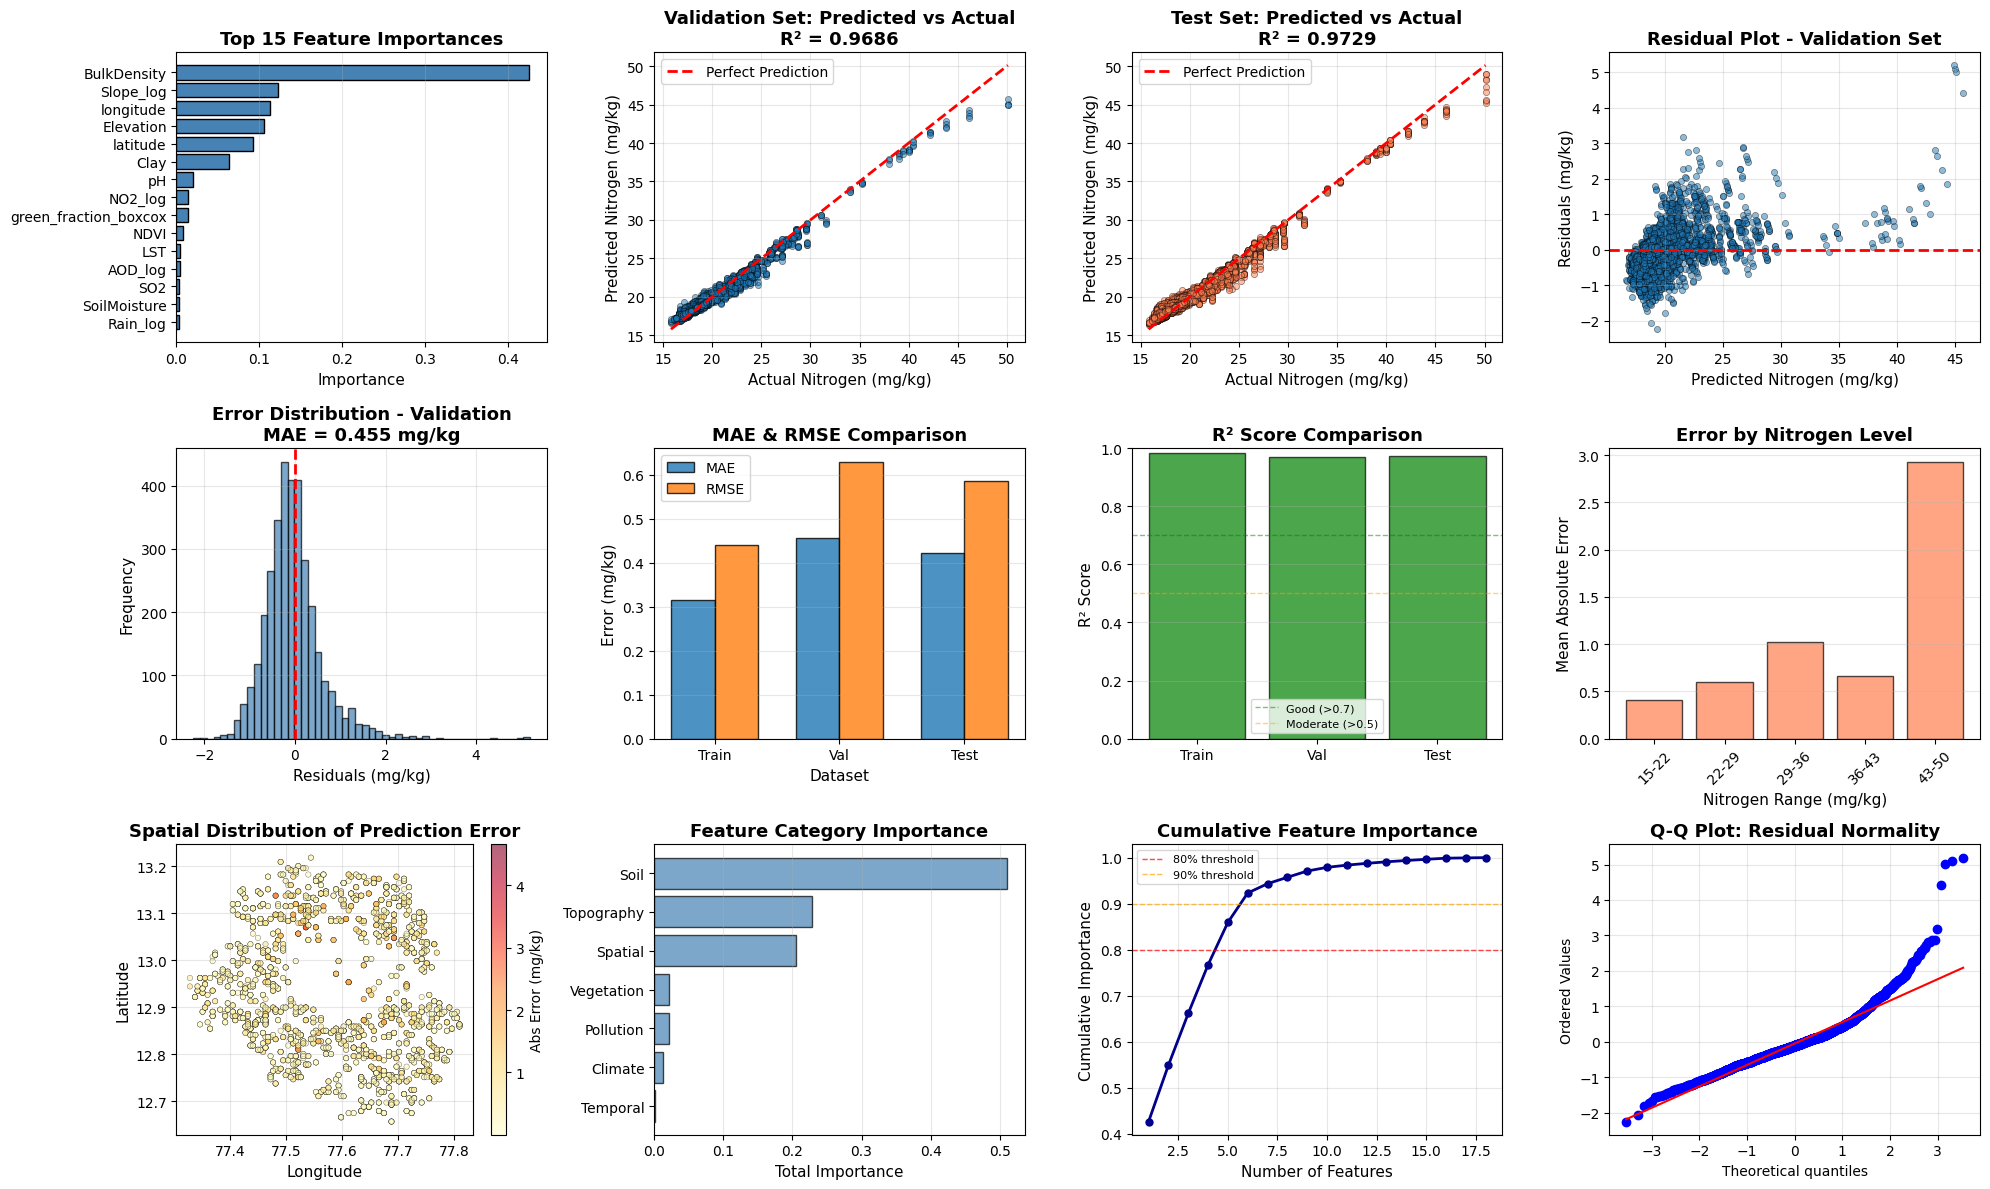

In [8]:
# ==============================================================================
# STEP 7: VISUALIZATIONS
# ==============================================================================
print("\n7. CREATING VISUALIZATIONS")
print("-" * 60)

fig = plt.figure(figsize=(20, 12))

# 1. Feature Importance
ax1 = plt.subplot(3, 4, 1)
top_n = 15
feature_importance_top = feature_importance.head(top_n)
plt.barh(range(top_n), feature_importance_top['Importance'], color='steelblue', edgecolor='black')
plt.yticks(range(top_n), feature_importance_top['Feature'])
plt.xlabel('Importance', fontsize=11)
plt.title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')

# 2. Predicted vs Actual (Validation)
ax2 = plt.subplot(3, 4, 2)
plt.scatter(y_val, y_val_pred, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Nitrogen (mg/kg)', fontsize=11)
plt.ylabel('Predicted Nitrogen (mg/kg)', fontsize=11)
plt.title(f'Validation Set: Predicted vs Actual\nR² = {metrics_val["R2"]:.4f}', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 3. Predicted vs Actual (Test)
ax3 = plt.subplot(3, 4, 3)
plt.scatter(y_test, y_test_pred, alpha=0.5, s=20, color='coral', edgecolor='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Nitrogen (mg/kg)', fontsize=11)
plt.ylabel('Predicted Nitrogen (mg/kg)', fontsize=11)
plt.title(f'Test Set: Predicted vs Actual\nR² = {metrics_test["R2"]:.4f}', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 4. Residual Plot (Validation)
ax4 = plt.subplot(3, 4, 4)
residuals_val = y_val - y_val_pred
plt.scatter(y_val_pred, residuals_val, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Nitrogen (mg/kg)', fontsize=11)
plt.ylabel('Residuals (mg/kg)', fontsize=11)
plt.title('Residual Plot - Validation Set', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)

# 5. Error Distribution (Validation)
ax5 = plt.subplot(3, 4, 5)
plt.hist(residuals_val, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Residuals (mg/kg)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title(f'Error Distribution - Validation\nMAE = {metrics_val["MAE"]:.3f} mg/kg', 
          fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)

# 6. Metrics Comparison
ax6 = plt.subplot(3, 4, 6)
metrics_df = pd.DataFrame({
    'Set': ['Train', 'Val', 'Test'],
    'MAE': [metrics_train['MAE'], metrics_val['MAE'], metrics_test['MAE']],
    'RMSE': [metrics_train['RMSE'], metrics_val['RMSE'], metrics_test['RMSE']]
})
x = np.arange(len(metrics_df))
width = 0.35
plt.bar(x - width/2, metrics_df['MAE'], width, label='MAE', alpha=0.8, edgecolor='black')
plt.bar(x + width/2, metrics_df['RMSE'], width, label='RMSE', alpha=0.8, edgecolor='black')
plt.xlabel('Dataset', fontsize=11)
plt.ylabel('Error (mg/kg)', fontsize=11)
plt.title('MAE & RMSE Comparison', fontsize=13, fontweight='bold')
plt.xticks(x, metrics_df['Set'])
plt.legend()
plt.grid(alpha=0.3, axis='y')

# 7. R² Comparison
ax7 = plt.subplot(3, 4, 7)
r2_values = [metrics_train['R2'], metrics_val['R2'], metrics_test['R2']]
colors = ['green' if r2 > 0.7 else 'orange' if r2 > 0.5 else 'red' for r2 in r2_values]
plt.bar(['Train', 'Val', 'Test'], r2_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('R² Score', fontsize=11)
plt.title('R² Score Comparison', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
plt.axhline(y=0.7, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Good (>0.7)')
plt.axhline(y=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Moderate (>0.5)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3, axis='y')

# 8. Prediction Error by Nitrogen Range (Validation)
ax8 = plt.subplot(3, 4, 8)
nitrogen_bins = pd.cut(y_val, bins=5)
error_by_bin = pd.DataFrame({
    'Bin': nitrogen_bins,
    'Error': np.abs(residuals_val)
}).groupby('Bin')['Error'].mean()
plt.bar(range(len(error_by_bin)), error_by_bin.values, alpha=0.7, edgecolor='black', color='coral')
plt.xlabel('Nitrogen Range (mg/kg)', fontsize=11)
plt.ylabel('Mean Absolute Error', fontsize=11)
plt.title('Error by Nitrogen Level', fontsize=13, fontweight='bold')
plt.xticks(range(len(error_by_bin)), [f'{int(b.left)}-{int(b.right)}' for b in error_by_bin.index], rotation=45)
plt.grid(alpha=0.3, axis='y')

# 9. Spatial Distribution of Errors (Test Set)
ax9 = plt.subplot(3, 4, 9)
test_df = df_sorted.loc[test_mask].copy()
test_df['prediction'] = y_test_pred
test_df['error'] = np.abs(y_test - y_test_pred)
sample_idx = np.random.choice(len(test_df), min(3000, len(test_df)), replace=False)
scatter = plt.scatter(test_df.iloc[sample_idx]['longitude'], 
                     test_df.iloc[sample_idx]['latitude'],
                     c=test_df.iloc[sample_idx]['error'],
                     cmap='YlOrRd', alpha=0.6, s=15, edgecolors='black', linewidth=0.3)
plt.xlabel('Longitude', fontsize=11)
plt.ylabel('Latitude', fontsize=11)
plt.title('Spatial Distribution of Prediction Error', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Abs Error (mg/kg)')
plt.grid(alpha=0.3)

# 10. Feature Category Importance
ax10 = plt.subplot(3, 4, 10)
feature_categories = {
    'Climate': ['Rain_log', 'Temp', 'LST', 'SoilMoisture'],
    'Vegetation': ['NDVI', 'green_fraction_boxcox'],
    'Soil': ['Clay', 'pH', 'BulkDensity'],
    'Topography': ['Elevation', 'Slope_log'],
    'Pollution': ['AOD_log', 'NO2_log', 'SO2'],
    'Temporal': ['Month_Sin', 'Month_Cos'],
    'Spatial': ['longitude', 'latitude']
}
category_importance = {}
for cat, feats in feature_categories.items():
    cat_imp = feature_importance[feature_importance['Feature'].isin(feats)]['Importance'].sum()
    category_importance[cat] = cat_imp

cat_df = pd.DataFrame(list(category_importance.items()), columns=['Category', 'Importance']).sort_values('Importance', ascending=False)
plt.barh(range(len(cat_df)), cat_df['Importance'], color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(cat_df)), cat_df['Category'])
plt.xlabel('Total Importance', fontsize=11)
plt.title('Feature Category Importance', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')

# 11. Cumulative Feature Importance
ax11 = plt.subplot(3, 4, 11)
cumulative_importance = np.cumsum(feature_importance['Importance'].values)
plt.plot(range(1, len(cumulative_importance)+1), cumulative_importance, 
         marker='o', linewidth=2, markersize=5, color='darkblue')
plt.axhline(y=0.8, color='red', linestyle='--', linewidth=1, alpha=0.7, label='80% threshold')
plt.axhline(y=0.9, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='90% threshold')
plt.xlabel('Number of Features', fontsize=11)
plt.ylabel('Cumulative Importance', fontsize=11)
plt.title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)

# 12. Q-Q Plot (Normality of Residuals)
ax12 = plt.subplot(3, 4, 12)
stats.probplot(residuals_val, dist="norm", plot=plt)
plt.title('Q-Q Plot: Residual Normality', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Option1_Nitrogen_Baseline_Results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Option1_Nitrogen_Baseline_Results.png")

In [9]:
# ==============================================================================
# STEP 8: SAVE RESULTS
# ==============================================================================
print("\n8. SAVING RESULTS")
print("-" * 60)

# Save predictions
results_df = pd.DataFrame({
    'Actual_Train': y_train,
    'Predicted_Train': y_train_pred
})
results_df.to_csv('Option1_predictions_train.csv', index=False)

results_val_df = pd.DataFrame({
    'Actual_Val': y_val,
    'Predicted_Val': y_val_pred
})
results_val_df.to_csv('Option1_predictions_val.csv', index=False)

results_test_df = pd.DataFrame({
    'Actual_Test': y_test,
    'Predicted_Test': y_test_pred
})
results_test_df.to_csv('Option1_predictions_test.csv', index=False)

# Save metrics
metrics_summary = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'MAE': [metrics_train['MAE'], metrics_val['MAE'], metrics_test['MAE']],
    'RMSE': [metrics_train['RMSE'], metrics_val['RMSE'], metrics_test['RMSE']],
    'R2': [metrics_train['R2'], metrics_val['R2'], metrics_test['R2']],
    'MAPE': [metrics_train['MAPE'], metrics_val['MAPE'], metrics_test['MAPE']]
})
metrics_summary.to_csv('Option1_metrics_summary.csv', index=False)

# Save feature importance
feature_importance.to_csv('Option1_feature_importance.csv', index=False)

# Save target variables
pd.DataFrame({'Nitrogen': y_train}).to_csv('Option1_y_train.csv', index=False)
pd.DataFrame({'Nitrogen': y_val}).to_csv('Option1_y_val.csv', index=False)
pd.DataFrame({'Nitrogen': y_test}).to_csv('Option1_y_test.csv', index=False)

print("✓ Saved all results:")
print("  - Option1_predictions_*.csv (predictions)")
print("  - Option1_metrics_summary.csv")
print("  - Option1_feature_importance.csv")
print("  - Option1_y_*.csv (target variables)")
print("  - Option1_Nitrogen_Baseline_Results.png")


8. SAVING RESULTS
------------------------------------------------------------
✓ Saved all results:
  - Option1_predictions_*.csv (predictions)
  - Option1_metrics_summary.csv
  - Option1_feature_importance.csv
  - Option1_y_*.csv (target variables)
  - Option1_Nitrogen_Baseline_Results.png


In [10]:
# ==============================================================================
# STEP 9: FINAL SUMMARY
# ==============================================================================
print("\n" + "="*80)
print("✅ OPTION 1: NITROGEN BASELINE MODEL - COMPLETE")
print("="*80)

print(f"\n📊 FINAL RESULTS:")
print(f"\nValidation Set:")
print(f"  MAE:  {metrics_val['MAE']:.3f} mg/kg")
print(f"  RMSE: {metrics_val['RMSE']:.3f} mg/kg")
print(f"  R²:   {metrics_val['R2']:.4f}")
print(f"  MAPE: {metrics_val['MAPE']:.2f}%")

print(f"\nTest Set:")
print(f"  MAE:  {metrics_test['MAE']:.3f} mg/kg")
print(f"  RMSE: {metrics_test['RMSE']:.3f} mg/kg")
print(f"  R²:   {metrics_test['R2']:.4f}")
print(f"  MAPE: {metrics_test['MAPE']:.2f}%")

print(f"\n🔑 KEY INSIGHTS:")
print(f"  • Target: Nitrogen (original, {y_train.min():.1f}-{y_train.max():.1f} mg/kg)")
print(f"  • Features: 18 (removed Nitrogen_log - NO DATA LEAKAGE)")
print(f"  • Top feature: {feature_importance.iloc[0]['Feature']}")
print(f"  • Model: Random Forest (200 trees, max_depth=20)")

if metrics_val['R2'] > 0.7:
    print(f"\n✅ EXCELLENT: R² > 0.7 on validation set")
elif metrics_val['R2'] > 0.5:
    print(f"\n✓ GOOD: R² > 0.5 on validation set")
else:
    print(f"\n⚠️  MODERATE: Consider feature engineering or hyperparameter tuning")

print(f"\n🎯 NEXT STEPS:")
print(f"  1. Review visualizations in Option1_Nitrogen_Baseline_Results.png")
print(f"  2. Check feature importance - does it make sense?")
print(f"  3. Compare with Option 2 (Composite FI with indirect features)")
print(f"  4. Tune hyperparameters if needed (GridSearchCV)")
print(f"  5. Try other models (XGBoost, LightGBM) for comparison")

print("\n" + "="*80)


✅ OPTION 1: NITROGEN BASELINE MODEL - COMPLETE

📊 FINAL RESULTS:

Validation Set:
  MAE:  0.455 mg/kg
  RMSE: 0.629 mg/kg
  R²:   0.9686
  MAPE: 2.25%

Test Set:
  MAE:  0.421 mg/kg
  RMSE: 0.586 mg/kg
  R²:   0.9729
  MAPE: 2.10%

🔑 KEY INSIGHTS:
  • Target: Nitrogen (original, 15.8-50.1 mg/kg)
  • Features: 18 (removed Nitrogen_log - NO DATA LEAKAGE)
  • Top feature: BulkDensity
  • Model: Random Forest (200 trees, max_depth=20)

✅ EXCELLENT: R² > 0.7 on validation set

🎯 NEXT STEPS:
  1. Review visualizations in Option1_Nitrogen_Baseline_Results.png
  2. Check feature importance - does it make sense?
  3. Compare with Option 2 (Composite FI with indirect features)
  4. Tune hyperparameters if needed (GridSearchCV)
  5. Try other models (XGBoost, LightGBM) for comparison



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("TASK 1: FERTILE SITE RECOMMENDATION - OPTION 2")
print("TARGET: Composite Fertility Index (Indirect Prediction)")
print("="*80)

# ==============================================================================
# STEP 1: LOAD DATA
# ==============================================================================
print("\n1. LOADING DATA")
print("-" * 60)

# Load original data
df_original = pd.read_csv('csv/Bangalore_Monthly_Final_Corrected.csv')
print(f"Original data shape: {df_original.shape}")

# Load preprocessed features
X_train = pd.read_csv('csv/X_train.csv')
X_val = pd.read_csv('csv/X_val.csv')
X_test = pd.read_csv('csv/X_test.csv')

print(f"\nPreprocessed features loaded:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

TASK 1: FERTILE SITE RECOMMENDATION - OPTION 2
TARGET: Composite Fertility Index (Indirect Prediction)

1. LOADING DATA
------------------------------------------------------------
Original data shape: (23042, 26)

Preprocessed features loaded:
  X_train: (11397, 19)
  X_val: (3397, 19)
  X_test: (8248, 19)


In [12]:
# ==============================================================================
# STEP 2: CREATE COMPOSITE FERTILITY INDEX (TARGET)
# ==============================================================================
print("\n2. CREATING COMPOSITE FERTILITY INDEX")
print("-" * 60)

# Parse date
df_original['date'] = pd.to_datetime(df_original['date'])
df_original['Year'] = df_original['date'].dt.year
df_original['Month_Actual'] = df_original['date'].dt.month

# Extract coordinates
import json
def extract_coordinates(geo_str):
    try:
        geo_dict = json.loads(geo_str)
        coords = geo_dict['coordinates']
        return coords[0], coords[1]
    except:
        return None, None

df_original['longitude'], df_original['latitude'] = zip(
    *df_original['.geo'].apply(extract_coordinates)
)

# Sort (must match preprocessing)
df_sorted = df_original.sort_values(['date', 'longitude', 'latitude']).reset_index(drop=True)

# Research-based weights
WEIGHTS = {
    'Nitrogen': 0.40,
    'pH': 0.25,
    'NDVI': 0.15,
    'SoilMoisture': 0.10,
    'Clay': 0.10
}

print(f"\nResearch-Based Weights:")
for comp, weight in WEIGHTS.items():
    print(f"  {comp:15s}: {weight:.2f}")

# Normalize components to [0, 1]
def normalize_minmax(values):
    scaler = MinMaxScaler()
    return scaler.fit_transform(values.values.reshape(-1, 1)).flatten()

def normalize_ph_optimal(ph_values, optimal=6.5, tolerance=1.0):
    deviation = np.abs(ph_values - optimal)
    scores = 1 - (deviation / tolerance)
    return np.clip(scores, 0, 1)

# Create normalized scores
df_sorted['N_score'] = normalize_minmax(df_sorted['Nitrogen'])
df_sorted['pH_score'] = normalize_ph_optimal(df_sorted['pH'])
df_sorted['NDVI_score'] = normalize_minmax(df_sorted['NDVI'])
df_sorted['Moisture_score'] = normalize_minmax(df_sorted['SoilMoisture'])
df_sorted['Clay_score'] = normalize_minmax(df_sorted['Clay'])

# Calculate Composite Fertility Index
df_sorted['FertilityIndex'] = (
    WEIGHTS['Nitrogen'] * df_sorted['N_score'] +
    WEIGHTS['pH'] * df_sorted['pH_score'] +
    WEIGHTS['NDVI'] * df_sorted['NDVI_score'] +
    WEIGHTS['SoilMoisture'] * df_sorted['Moisture_score'] +
    WEIGHTS['Clay'] * df_sorted['Clay_score']
)

# Create fertility classes
def classify_fertility(fi_score):
    if fi_score >= 0.7:
        return 'High'
    elif fi_score >= 0.4:
        return 'Medium'
    else:
        return 'Low'

df_sorted['FertilityClass'] = df_sorted['FertilityIndex'].apply(classify_fertility)

print(f"\n✓ Fertility Index created")
print(f"  Range: [{df_sorted['FertilityIndex'].min():.3f}, {df_sorted['FertilityIndex'].max():.3f}]")
print(f"  Mean: {df_sorted['FertilityIndex'].mean():.3f} ± {df_sorted['FertilityIndex'].std():.3f}")


2. CREATING COMPOSITE FERTILITY INDEX
------------------------------------------------------------

Research-Based Weights:
  Nitrogen       : 0.40
  pH             : 0.25
  NDVI           : 0.15
  SoilMoisture   : 0.10
  Clay           : 0.10

✓ Fertility Index created
  Range: [0.266, 0.842]
  Mean: 0.418 ± 0.058


In [13]:
# ==============================================================================
# STEP 3: EXTRACT TARGETS
# ==============================================================================
print("\n3. EXTRACTING TARGETS")
print("-" * 60)

# Create same masks as preprocessing
train_mask = ((df_sorted['Year'] == 2021) | 
              ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] <= 6)))
val_mask = ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] >= 7))
test_mask = df_sorted['Year'] == 2023

# Extract targets
y_train = df_sorted.loc[train_mask, 'FertilityIndex'].values
y_val = df_sorted.loc[val_mask, 'FertilityIndex'].values
y_test = df_sorted.loc[test_mask, 'FertilityIndex'].values

y_train_class = df_sorted.loc[train_mask, 'FertilityClass'].values
y_val_class = df_sorted.loc[val_mask, 'FertilityClass'].values
y_test_class = df_sorted.loc[test_mask, 'FertilityClass'].values

print(f"Target statistics:")
print(f"  Train: {len(y_train)} samples, FI range [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"  Val:   {len(y_val)} samples, FI range [{y_val.min():.3f}, {y_val.max():.3f}]")
print(f"  Test:  {len(y_test)} samples, FI range [{y_test.min():.3f}, {y_test.max():.3f}]")

print(f"\nClass distribution (Validation):")
class_counts = pd.Series(y_val_class).value_counts()
for cls in ['High', 'Medium', 'Low']:
    if cls in class_counts.index:
        print(f"  {cls}: {class_counts[cls]} ({class_counts[cls]/len(y_val_class)*100:.1f}%)")


3. EXTRACTING TARGETS
------------------------------------------------------------
Target statistics:
  Train: 11397 samples, FI range [0.266, 0.842]
  Val:   3397 samples, FI range [0.349, 0.814]
  Test:  8248 samples, FI range [0.274, 0.816]

Class distribution (Validation):
  High: 26 (0.8%)
  Medium: 2977 (87.6%)
  Low: 394 (11.6%)


In [14]:
# ==============================================================================
# STEP 4: REMOVE ALL FI COMPONENTS FROM FEATURES (NO DATA LEAKAGE)
# ==============================================================================
print("\n4. REMOVING ALL FI COMPONENTS FROM FEATURES")
print("-" * 60)

# Features to REMOVE (all 5 FI components)
components_to_remove = [
    'Nitrogen_log',     # Component 1
    'pH',               # Component 2
    'NDVI',             # Component 3
    'SoilMoisture',     # Component 4
    'Clay'              # Component 5
]

# Features to KEEP (14 environmental features)
features_to_keep = [
    # Climate (3) - removed SoilMoisture!
    'Rain_log', 'Temp', 'LST',
    
    # Vegetation (1) - removed NDVI!
    'green_fraction_boxcox',
    
    # Soil (1) - removed Clay, pH, Nitrogen_log!
    'BulkDensity',
    
    # Topography (2)
    'Elevation', 'Slope_log',
    
    # Pollution (3)
    'AOD_log', 'NO2_log', 'SO2',
    
    # Temporal (2)
    'Month_Sin', 'Month_Cos',
    
    # Spatial (2)
    'longitude', 'latitude'
]

print(f"Original features: {X_train.shape[1]}")
print(f"Components removed: {len(components_to_remove)}")
print(f"  - {', '.join(components_to_remove)}")
print(f"Final features: {len(features_to_keep)}")

# Verify no FI components in features
for comp in components_to_remove:
    if comp in features_to_keep:
        raise ValueError(f"ERROR: {comp} still in features! Data leakage!")

print("✓ Confirmed: ALL FI components removed - NO DATA LEAKAGE")

# Select features
X_train_clean = X_train[features_to_keep].copy()
X_val_clean = X_val[features_to_keep].copy()
X_test_clean = X_test[features_to_keep].copy()

print(f"\nFinal feature sets:")
print(f"  X_train: {X_train_clean.shape}")
print(f"  X_val: {X_val_clean.shape}")
print(f"  X_test: {X_test_clean.shape}")

print(f"\nFeature Categories (Environmental Only):")
print(f"  Climate: Rain_log, Temp, LST")
print(f"  Vegetation: green_fraction_boxcox")
print(f"  Soil: BulkDensity")
print(f"  Topography: Elevation, Slope_log")
print(f"  Pollution: AOD_log, NO2_log, SO2")
print(f"  Temporal: Month_Sin, Month_Cos")
print(f"  Spatial: longitude, latitude")


4. REMOVING ALL FI COMPONENTS FROM FEATURES
------------------------------------------------------------
Original features: 19
Components removed: 5
  - Nitrogen_log, pH, NDVI, SoilMoisture, Clay
Final features: 14
✓ Confirmed: ALL FI components removed - NO DATA LEAKAGE

Final feature sets:
  X_train: (11397, 14)
  X_val: (3397, 14)
  X_test: (8248, 14)

Feature Categories (Environmental Only):
  Climate: Rain_log, Temp, LST
  Vegetation: green_fraction_boxcox
  Soil: BulkDensity
  Topography: Elevation, Slope_log
  Pollution: AOD_log, NO2_log, SO2
  Temporal: Month_Sin, Month_Cos
  Spatial: longitude, latitude


In [15]:
# ==============================================================================
# STEP 5: TRAIN REGRESSION MODEL (FertilityIndex)
# ==============================================================================
print("\n5. TRAINING REGRESSION MODEL (Fertility Index Prediction)")
print("-" * 60)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Regression model hyperparameters:")
print(f"  n_estimators: {rf_reg.n_estimators}")
print(f"  max_depth: {rf_reg.max_depth}")

print("\nTraining...")
rf_reg.fit(X_train_clean, y_train)
print("✓ Regression model trained!")

# Predictions
y_train_pred = rf_reg.predict(X_train_clean)
y_val_pred = rf_reg.predict(X_val_clean)
y_test_pred = rf_reg.predict(X_test_clean)

# Metrics
def calculate_metrics(y_true, y_pred, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    print(f"\n{set_name} Set Metrics (Regression):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

metrics_train_reg = calculate_metrics(y_train, y_train_pred, "Training")
metrics_val_reg = calculate_metrics(y_val, y_val_pred, "Validation")
metrics_test_reg = calculate_metrics(y_test, y_test_pred, "Test")


5. TRAINING REGRESSION MODEL (Fertility Index Prediction)
------------------------------------------------------------
Regression model hyperparameters:
  n_estimators: 200
  max_depth: 20

Training...
✓ Regression model trained!

Training Set Metrics (Regression):
  MAE:  0.0130
  RMSE: 0.0170
  R²:   0.9157
  MAPE: 3.11%

Validation Set Metrics (Regression):
  MAE:  0.0248
  RMSE: 0.0316
  R²:   0.6324
  MAPE: 5.37%

Test Set Metrics (Regression):
  MAE:  0.0230
  RMSE: 0.0296
  R²:   0.7103
  MAPE: 5.91%


In [16]:
# ==============================================================================
# STEP 6: TRAIN CLASSIFICATION MODEL (FertilityClass)
# ==============================================================================
print("\n6. TRAINING CLASSIFICATION MODEL (Fertility Class Prediction)")
print("-" * 60)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)

print("Classification model hyperparameters:")
print(f"  n_estimators: {rf_clf.n_estimators}")
print(f"  class_weight: balanced")

print("\nTraining...")
rf_clf.fit(X_train_clean, y_train_class)
print("✓ Classification model trained!")

# Predictions
y_train_class_pred = rf_clf.predict(X_train_clean)
y_val_class_pred = rf_clf.predict(X_val_clean)
y_test_class_pred = rf_clf.predict(X_test_clean)

# Metrics
print(f"\nValidation Set Metrics (Classification):")
val_acc = accuracy_score(y_val_class, y_val_class_pred)
print(f"  Accuracy: {val_acc:.4f}")

print(f"\nTest Set Metrics (Classification):")
test_acc = accuracy_score(y_test_class, y_test_class_pred)
print(f"  Accuracy: {test_acc:.4f}")

print(f"\nClassification Report (Validation):")
print(classification_report(y_val_class, y_val_class_pred))


6. TRAINING CLASSIFICATION MODEL (Fertility Class Prediction)
------------------------------------------------------------
Classification model hyperparameters:
  n_estimators: 200
  class_weight: balanced

Training...
✓ Classification model trained!

Validation Set Metrics (Classification):
  Accuracy: 0.8596

Test Set Metrics (Classification):
  Accuracy: 0.7915

Classification Report (Validation):
              precision    recall  f1-score   support

        High       1.00      0.96      0.98        26
         Low       0.39      0.37      0.38       394
      Medium       0.92      0.92      0.92      2977

    accuracy                           0.86      3397
   macro avg       0.77      0.75      0.76      3397
weighted avg       0.86      0.86      0.86      3397



In [17]:
# ==============================================================================
# STEP 7: FEATURE IMPORTANCE
# ==============================================================================
print("\n7. FEATURE IMPORTANCE ANALYSIS")
print("-" * 60)

feature_importance_reg = pd.DataFrame({
    'Feature': features_to_keep,
    'Importance_Regression': rf_reg.feature_importances_,
    'Importance_Classification': rf_clf.feature_importances_
}).sort_values('Importance_Regression', ascending=False)

print("\nTop 10 Features (Regression):")
print(feature_importance_reg[['Feature', 'Importance_Regression']].head(10).to_string(index=False))

print("\n✓ Verification: No FI components in feature list")
print(f"✓ Top feature: {feature_importance_reg.iloc[0]['Feature']}")


7. FEATURE IMPORTANCE ANALYSIS
------------------------------------------------------------

Top 10 Features (Regression):
              Feature  Importance_Regression
          BulkDensity               0.281558
             latitude               0.170381
green_fraction_boxcox               0.110691
                  LST               0.084587
            Slope_log               0.069081
            longitude               0.064470
            Elevation               0.048549
                 Temp               0.041038
            Month_Cos               0.025668
             Rain_log               0.024802

✓ Verification: No FI components in feature list
✓ Top feature: BulkDensity



8. CREATING VISUALIZATIONS
------------------------------------------------------------
✓ Saved: Option2_FertilityIndex_Baseline_Results.png


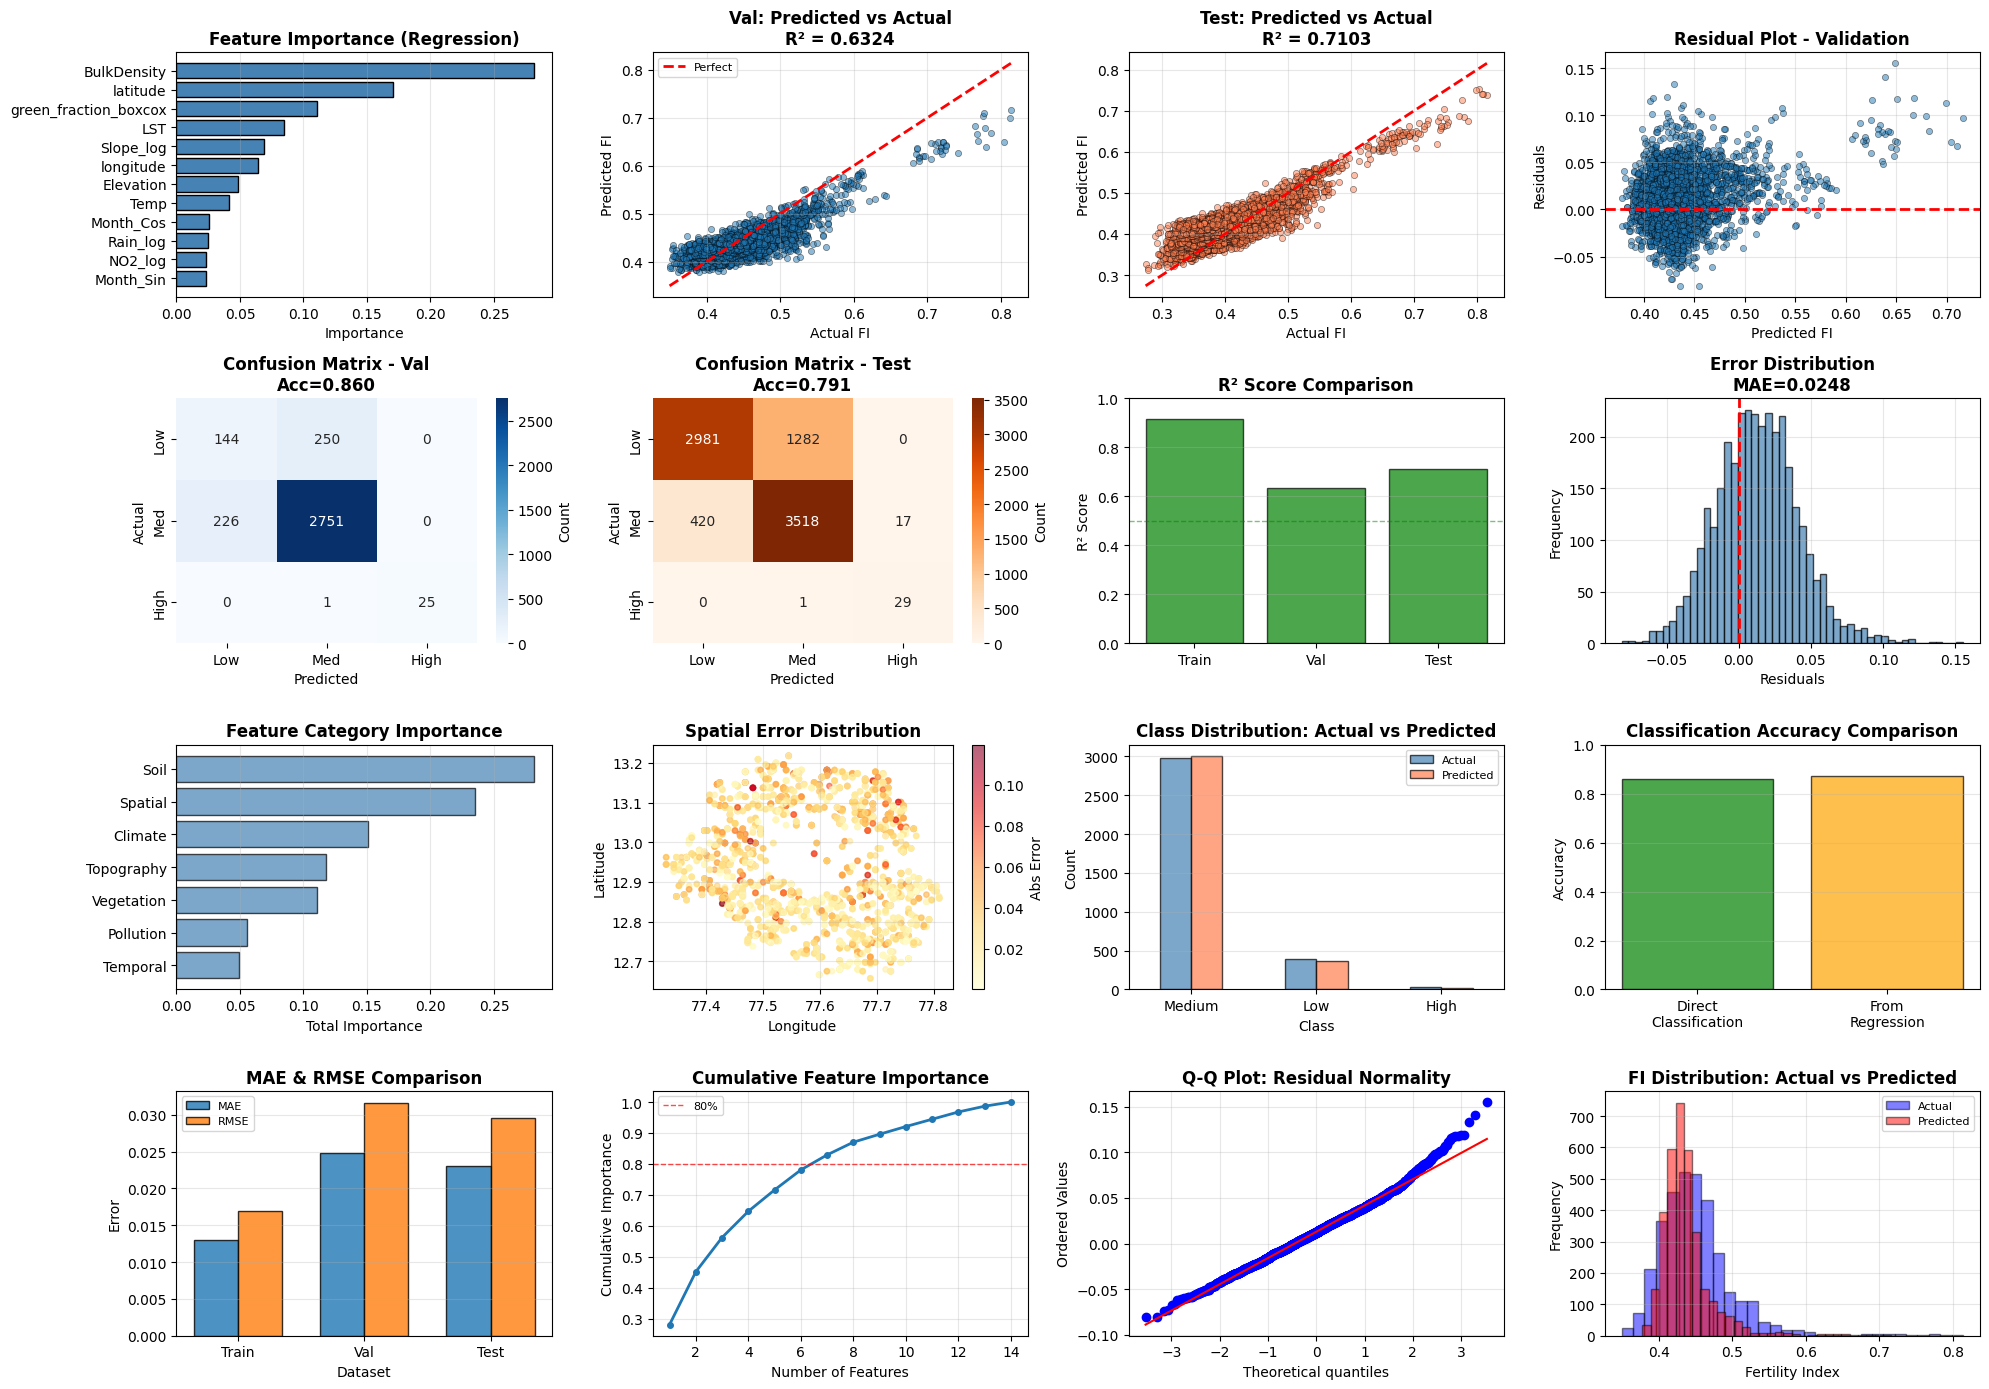

In [18]:
# ==============================================================================
# STEP 8: VISUALIZATIONS
# ==============================================================================
print("\n8. CREATING VISUALIZATIONS")
print("-" * 60)

fig = plt.figure(figsize=(20, 14))

# 1. Feature Importance (Regression)
ax1 = plt.subplot(4, 4, 1)
top_n = 12
fi_top = feature_importance_reg.head(top_n)
plt.barh(range(top_n), fi_top['Importance_Regression'], color='steelblue', edgecolor='black')
plt.yticks(range(top_n), fi_top['Feature'])
plt.xlabel('Importance', fontsize=10)
plt.title('Feature Importance (Regression)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')

# 2. Predicted vs Actual (Validation - Regression)
ax2 = plt.subplot(4, 4, 2)
plt.scatter(y_val, y_val_pred, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
         'r--', linewidth=2, label='Perfect')
plt.xlabel('Actual FI', fontsize=10)
plt.ylabel('Predicted FI', fontsize=10)
plt.title(f'Val: Predicted vs Actual\nR² = {metrics_val_reg["R2"]:.4f}', 
          fontsize=12, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 3. Predicted vs Actual (Test - Regression)
ax3 = plt.subplot(4, 4, 3)
plt.scatter(y_test, y_test_pred, alpha=0.5, s=20, color='coral', edgecolor='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel('Actual FI', fontsize=10)
plt.ylabel('Predicted FI', fontsize=10)
plt.title(f'Test: Predicted vs Actual\nR² = {metrics_test_reg["R2"]:.4f}', 
          fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

# 4. Residual Plot
ax4 = plt.subplot(4, 4, 4)
residuals_val = y_val - y_val_pred
plt.scatter(y_val_pred, residuals_val, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted FI', fontsize=10)
plt.ylabel('Residuals', fontsize=10)
plt.title('Residual Plot - Validation', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

# 5. Confusion Matrix (Validation - Classification)
ax5 = plt.subplot(4, 4, 5)
cm = confusion_matrix(y_val_class, y_val_class_pred, labels=['Low', 'Medium', 'High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Med', 'High'],
            yticklabels=['Low', 'Med', 'High'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=10)
plt.ylabel('Actual', fontsize=10)
plt.title(f'Confusion Matrix - Val\nAcc={val_acc:.3f}', fontsize=12, fontweight='bold')

# 6. Confusion Matrix (Test - Classification)
ax6 = plt.subplot(4, 4, 6)
cm_test = confusion_matrix(y_test_class, y_test_class_pred, labels=['Low', 'Medium', 'High'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low', 'Med', 'High'],
            yticklabels=['Low', 'Med', 'High'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=10)
plt.ylabel('Actual', fontsize=10)
plt.title(f'Confusion Matrix - Test\nAcc={test_acc:.3f}', fontsize=12, fontweight='bold')

# 7. R² Comparison
ax7 = plt.subplot(4, 4, 7)
r2_values = [metrics_train_reg['R2'], metrics_val_reg['R2'], metrics_test_reg['R2']]
colors = ['green' if r2 > 0.5 else 'orange' if r2 > 0.3 else 'red' for r2 in r2_values]
plt.bar(['Train', 'Val', 'Test'], r2_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('R² Score', fontsize=10)
plt.title('R² Score Comparison', fontsize=12, fontweight='bold')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, linewidth=1)
plt.grid(alpha=0.3, axis='y')

# 8. Error Distribution
ax8 = plt.subplot(4, 4, 8)
plt.hist(residuals_val, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Residuals', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title(f'Error Distribution\nMAE={metrics_val_reg["MAE"]:.4f}', 
          fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

# 9. Feature Category Importance
ax9 = plt.subplot(4, 4, 9)
feature_categories = {
    'Climate': ['Rain_log', 'Temp', 'LST'],
    'Vegetation': ['green_fraction_boxcox'],
    'Soil': ['BulkDensity'],
    'Topography': ['Elevation', 'Slope_log'],
    'Pollution': ['AOD_log', 'NO2_log', 'SO2'],
    'Temporal': ['Month_Sin', 'Month_Cos'],
    'Spatial': ['longitude', 'latitude']
}
category_importance = {}
for cat, feats in feature_categories.items():
    cat_imp = feature_importance_reg[feature_importance_reg['Feature'].isin(feats)]['Importance_Regression'].sum()
    category_importance[cat] = cat_imp

cat_df = pd.DataFrame(list(category_importance.items()), columns=['Category', 'Importance']).sort_values('Importance', ascending=False)
plt.barh(range(len(cat_df)), cat_df['Importance'], color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(cat_df)), cat_df['Category'])
plt.xlabel('Total Importance', fontsize=10)
plt.title('Feature Category Importance', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')

# 10. Spatial Distribution of Errors
ax10 = plt.subplot(4, 4, 10)
test_df = df_sorted.loc[test_mask].copy()
test_df['prediction'] = y_test_pred
test_df['error'] = np.abs(y_test - y_test_pred)
sample_idx = np.random.choice(len(test_df), min(3000, len(test_df)), replace=False)
scatter = plt.scatter(test_df.iloc[sample_idx]['longitude'], 
                     test_df.iloc[sample_idx]['latitude'],
                     c=test_df.iloc[sample_idx]['error'],
                     cmap='YlOrRd', alpha=0.6, s=15)
plt.xlabel('Longitude', fontsize=10)
plt.ylabel('Latitude', fontsize=10)
plt.title('Spatial Error Distribution', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Abs Error')
plt.grid(alpha=0.3)

# 11. Class Distribution Comparison
ax11 = plt.subplot(4, 4, 11)
class_comparison = pd.DataFrame({
    'Actual': pd.Series(y_val_class).value_counts(),
    'Predicted': pd.Series(y_val_class_pred).value_counts()
})
class_comparison.plot(kind='bar', ax=ax11, color=['steelblue', 'coral'], 
                      alpha=0.7, edgecolor='black')
plt.xlabel('Class', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.title('Class Distribution: Actual vs Predicted', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(fontsize=8)
plt.grid(alpha=0.3, axis='y')

# 12. Regression vs Classification Comparison
ax12 = plt.subplot(4, 4, 12)
# Convert regression predictions to classes
y_val_pred_class_from_reg = [classify_fertility(fi) for fi in y_val_pred]
acc_from_reg = accuracy_score(y_val_class, y_val_pred_class_from_reg)
comparison_df = pd.DataFrame({
    'Method': ['Direct\nClassification', 'From\nRegression'],
    'Accuracy': [val_acc, acc_from_reg]
})
plt.bar(comparison_df['Method'], comparison_df['Accuracy'], 
        color=['green', 'orange'], alpha=0.7, edgecolor='black')
plt.ylabel('Accuracy', fontsize=10)
plt.title('Classification Accuracy Comparison', fontsize=12, fontweight='bold')
plt.ylim(0, 1)
plt.grid(alpha=0.3, axis='y')

# 13. Metrics Summary
ax13 = plt.subplot(4, 4, 13)
metrics_comparison = pd.DataFrame({
    'Set': ['Train', 'Val', 'Test'],
    'MAE': [metrics_train_reg['MAE'], metrics_val_reg['MAE'], metrics_test_reg['MAE']],
    'RMSE': [metrics_train_reg['RMSE'], metrics_val_reg['RMSE'], metrics_test_reg['RMSE']]
})
x = np.arange(len(metrics_comparison))
width = 0.35
plt.bar(x - width/2, metrics_comparison['MAE'], width, label='MAE', alpha=0.8, edgecolor='black')
plt.bar(x + width/2, metrics_comparison['RMSE'], width, label='RMSE', alpha=0.8, edgecolor='black')
plt.xlabel('Dataset', fontsize=10)
plt.ylabel('Error', fontsize=10)
plt.title('MAE & RMSE Comparison', fontsize=12, fontweight='bold')
plt.xticks(x, metrics_comparison['Set'])
plt.legend(fontsize=8)
plt.grid(alpha=0.3, axis='y')

# 14. Cumulative Feature Importance
ax14 = plt.subplot(4, 4, 14)
cumulative = np.cumsum(feature_importance_reg['Importance_Regression'].values)
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o', linewidth=2, markersize=4)
plt.axhline(y=0.8, color='red', linestyle='--', linewidth=1, alpha=0.7, label='80%')
plt.xlabel('Number of Features', fontsize=10)
plt.ylabel('Cumulative Importance', fontsize=10)
plt.title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 15. Q-Q Plot
ax15 = plt.subplot(4, 4, 15)
stats.probplot(residuals_val, dist="norm", plot=plt)
plt.title('Q-Q Plot: Residual Normality', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

# 16. FI Distribution: Actual vs Predicted
ax16 = plt.subplot(4, 4, 16)
plt.hist(y_val, bins=30, alpha=0.5, label='Actual', edgecolor='black', color='blue')
plt.hist(y_val_pred, bins=30, alpha=0.5, label='Predicted', edgecolor='black', color='red')
plt.xlabel('Fertility Index', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('FI Distribution: Actual vs Predicted', fontsize=12, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Option2_FertilityIndex_Baseline_Results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Option2_FertilityIndex_Baseline_Results.png")

In [19]:
# ==============================================================================
# STEP 9: SAVE RESULTS
# ==============================================================================
print("\n9. SAVING RESULTS")
print("-" * 60)

# Save predictions (regression)
pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred}).to_csv('Option2_predictions_train_reg.csv', index=False)
pd.DataFrame({'Actual': y_val, 'Predicted': y_val_pred}).to_csv('Option2_predictions_val_reg.csv', index=False)
pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred}).to_csv('Option2_predictions_test_reg.csv', index=False)

# Save predictions (classification)
pd.DataFrame({'Actual': y_train_class, 'Predicted': y_train_class_pred}).to_csv('Option2_predictions_train_class.csv', index=False)
pd.DataFrame({'Actual': y_val_class, 'Predicted': y_val_class_pred}).to_csv('Option2_predictions_val_class.csv', index=False)
pd.DataFrame({'Actual': y_test_class, 'Predicted': y_test_class_pred}).to_csv('Option2_predictions_test_class.csv', index=False)

# Save metrics
pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'MAE': [metrics_train_reg['MAE'], metrics_val_reg['MAE'], metrics_test_reg['MAE']],
    'RMSE': [metrics_train_reg['RMSE'], metrics_val_reg['RMSE'], metrics_test_reg['RMSE']],
    'R2': [metrics_train_reg['R2'], metrics_val_reg['R2'], metrics_test_reg['R2']],
    'MAPE': [metrics_train_reg['MAPE'], metrics_val_reg['MAPE'], metrics_test_reg['MAPE']]
}).to_csv('Option2_metrics_regression.csv', index=False)

pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'Accuracy': [
        accuracy_score(y_train_class, y_train_class_pred),
        accuracy_score(y_val_class, y_val_class_pred),
        accuracy_score(y_test_class, y_test_class_pred)
    ]
}).to_csv('Option2_metrics_classification.csv', index=False)

# Save feature importance
feature_importance_reg.to_csv('Option2_feature_importance.csv', index=False)

# Save targets
pd.DataFrame({'FertilityIndex': y_train}).to_csv('Option2_y_train.csv', index=False)
pd.DataFrame({'FertilityIndex': y_val}).to_csv('Option2_y_val.csv', index=False)
pd.DataFrame({'FertilityIndex': y_test}).to_csv('Option2_y_test.csv', index=False)
pd.DataFrame({'FertilityClass': y_train_class}).to_csv('Option2_y_train_class.csv', index=False)
pd.DataFrame({'FertilityClass': y_val_class}).to_csv('Option2_y_val_class.csv', index=False)
pd.DataFrame({'FertilityClass': y_test_class}).to_csv('Option2_y_test_class.csv', index=False)

print("✓ Saved all results")


9. SAVING RESULTS
------------------------------------------------------------
✓ Saved all results


In [20]:
# ==============================================================================
# STEP 10: FINAL SUMMARY
# ==============================================================================
print("\n" + "="*80)
print("✅ OPTION 2: COMPOSITE FI BASELINE MODEL - COMPLETE")
print("="*80)

print(f"\n📊 REGRESSION RESULTS (Fertility Index):")
print(f"\nValidation Set:")
print(f"  MAE:  {metrics_val_reg['MAE']:.4f}")
print(f"  RMSE: {metrics_val_reg['RMSE']:.4f}")
print(f"  R²:   {metrics_val_reg['R2']:.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {metrics_test_reg['MAE']:.4f}")
print(f"  RMSE: {metrics_test_reg['RMSE']:.4f}")
print(f"  R²:   {metrics_test_reg['R2']:.4f}")

print(f"\n📊 CLASSIFICATION RESULTS (Fertility Class):")
print(f"  Validation Accuracy: {val_acc:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")

print(f"\n🔑 KEY INSIGHTS:")
print(f"  • Target: Composite Fertility Index (0-1 scale)")
print(f"  • Features: 14 environmental (NO direct soil/plant measures)")
print(f"  • Removed: Nitrogen, pH, NDVI, SoilMoisture, Clay")
print(f"  • Top feature: {feature_importance_reg.iloc[0]['Feature']}")
print(f"  • Model learns INDIRECT relationships (weather → fertility)")

if metrics_val_reg['R2'] > 0.5:
    print(f"\n✓ GOOD: R² > 0.5 - Model captures environmental effects")
elif metrics_val_reg['R2'] > 0.3:
    print(f"\n⚠️  MODERATE: R² > 0.3 - Consider feature engineering")
else:
    print(f"\n⚠️  WEAK: R² < 0.3 - Indirect prediction is challenging")

print(f"\n🎯 COMPARISON WITH OPTION 1:")
print(f"  Option 1: Direct Nitrogen prediction (18 features)")
print(f"  Option 2: Indirect FI prediction (14 features)")
print(f"  → Compare R² and MAE to see which works better")

print("\n" + "="*80)


✅ OPTION 2: COMPOSITE FI BASELINE MODEL - COMPLETE

📊 REGRESSION RESULTS (Fertility Index):

Validation Set:
  MAE:  0.0248
  RMSE: 0.0316
  R²:   0.6324

Test Set:
  MAE:  0.0230
  RMSE: 0.0296
  R²:   0.7103

📊 CLASSIFICATION RESULTS (Fertility Class):
  Validation Accuracy: 0.8596
  Test Accuracy: 0.7915

🔑 KEY INSIGHTS:
  • Target: Composite Fertility Index (0-1 scale)
  • Features: 14 environmental (NO direct soil/plant measures)
  • Removed: Nitrogen, pH, NDVI, SoilMoisture, Clay
  • Top feature: BulkDensity
  • Model learns INDIRECT relationships (weather → fertility)

✓ GOOD: R² > 0.5 - Model captures environmental effects

🎯 COMPARISON WITH OPTION 1:
  Option 1: Direct Nitrogen prediction (18 features)
  Option 2: Indirect FI prediction (14 features)
  → Compare R² and MAE to see which works better



In [21]:
"""
TASK 1: FERTILE SITE RECOMMENDATION - OPTION 2 IMPROVED
Target: Composite Fertility Index (Regression Only)
Models: Random Forest + XGBoost with TimeSeriesSplit Cross-Validation

Improvements:
1. Removed classification (due to class imbalance)
2. Added XGBoost for comparison
3. Added TimeSeriesSplit cross-validation (respects temporal order)
4. More robust evaluation

NO DATA LEAKAGE - All FI components removed from features
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Check if XGBoost is available
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost is available")
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not available")
    if "OpenMP" in str(e) or "libomp" in str(e):
        print("   Reason: OpenMP library missing - run: brew install libomp")
    else:
        print(f"   Reason: {str(e)[:100]}")
    print("   Continuing with Random Forest only...")

print("="*80)
print("TASK 1: FERTILE SITE RECOMMENDATION - OPTION 2 IMPROVED")
print("TARGET: Composite Fertility Index (Regression Only)")
print("="*80)

# ==============================================================================
# STEP 1: LOAD DATA
# ==============================================================================
print("\n1. LOADING DATA")
print("-" * 60)

df_original = pd.read_csv('csv/Bangalore_Monthly_Final_Corrected.csv')
print(f"Original data shape: {df_original.shape}")

X_train = pd.read_csv('csv/X_train.csv')
X_val = pd.read_csv('csv/X_val.csv')
X_test = pd.read_csv('csv/X_test.csv')

print(f"\nPreprocessed features loaded:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

✓ XGBoost is available
TASK 1: FERTILE SITE RECOMMENDATION - OPTION 2 IMPROVED
TARGET: Composite Fertility Index (Regression Only)

1. LOADING DATA
------------------------------------------------------------
Original data shape: (23042, 26)

Preprocessed features loaded:
  X_train: (11397, 19)
  X_val: (3397, 19)
  X_test: (8248, 19)


In [22]:
# ==============================================================================
# STEP 2: CREATE COMPOSITE FERTILITY INDEX
# ==============================================================================
print("\n2. CREATING COMPOSITE FERTILITY INDEX")
print("-" * 60)

df_original['date'] = pd.to_datetime(df_original['date'])
df_original['Year'] = df_original['date'].dt.year
df_original['Month_Actual'] = df_original['date'].dt.month

import json
def extract_coordinates(geo_str):
    try:
        geo_dict = json.loads(geo_str)
        coords = geo_dict['coordinates']
        return coords[0], coords[1]
    except:
        return None, None

df_original['longitude'], df_original['latitude'] = zip(
    *df_original['.geo'].apply(extract_coordinates)
)

df_sorted = df_original.sort_values(['date', 'longitude', 'latitude']).reset_index(drop=True)

# Research-based weights
WEIGHTS = {
    'Nitrogen': 0.40,
    'pH': 0.25,
    'NDVI': 0.15,
    'SoilMoisture': 0.10,
    'Clay': 0.10
}

print(f"\nResearch-Based Weights:")
for comp, weight in WEIGHTS.items():
    print(f"  {comp:15s}: {weight:.2f}")

# Normalization functions
def normalize_minmax(values):
    scaler = MinMaxScaler()
    return scaler.fit_transform(values.values.reshape(-1, 1)).flatten()

def normalize_ph_optimal(ph_values, optimal=6.5, tolerance=1.0):
    deviation = np.abs(ph_values - optimal)
    scores = 1 - (deviation / tolerance)
    return np.clip(scores, 0, 1)

# Create normalized scores
df_sorted['N_score'] = normalize_minmax(df_sorted['Nitrogen'])
df_sorted['pH_score'] = normalize_ph_optimal(df_sorted['pH'])
df_sorted['NDVI_score'] = normalize_minmax(df_sorted['NDVI'])
df_sorted['Moisture_score'] = normalize_minmax(df_sorted['SoilMoisture'])
df_sorted['Clay_score'] = normalize_minmax(df_sorted['Clay'])

# Calculate Composite Fertility Index
df_sorted['FertilityIndex'] = (
    WEIGHTS['Nitrogen'] * df_sorted['N_score'] +
    WEIGHTS['pH'] * df_sorted['pH_score'] +
    WEIGHTS['NDVI'] * df_sorted['NDVI_score'] +
    WEIGHTS['SoilMoisture'] * df_sorted['Moisture_score'] +
    WEIGHTS['Clay'] * df_sorted['Clay_score']
)

print(f"\n✓ Fertility Index created")
print(f"  Range: [{df_sorted['FertilityIndex'].min():.3f}, {df_sorted['FertilityIndex'].max():.3f}]")
print(f"  Mean: {df_sorted['FertilityIndex'].mean():.3f} ± {df_sorted['FertilityIndex'].std():.3f}")
print(f"  Median: {df_sorted['FertilityIndex'].median():.3f}")
print(f"  25th percentile: {df_sorted['FertilityIndex'].quantile(0.25):.3f}")
print(f"  75th percentile: {df_sorted['FertilityIndex'].quantile(0.75):.3f}")


2. CREATING COMPOSITE FERTILITY INDEX
------------------------------------------------------------

Research-Based Weights:
  Nitrogen       : 0.40
  pH             : 0.25
  NDVI           : 0.15
  SoilMoisture   : 0.10
  Clay           : 0.10

✓ Fertility Index created
  Range: [0.266, 0.842]
  Mean: 0.418 ± 0.058
  Median: 0.411
  25th percentile: 0.381
  75th percentile: 0.446


In [23]:
# ==============================================================================
# STEP 3: EXTRACT TARGETS
# ==============================================================================
print("\n3. EXTRACTING TARGETS")
print("-" * 60)

train_mask = ((df_sorted['Year'] == 2021) | 
              ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] <= 6)))
val_mask = ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] >= 7))
test_mask = df_sorted['Year'] == 2023

y_train = df_sorted.loc[train_mask, 'FertilityIndex'].values
y_val = df_sorted.loc[val_mask, 'FertilityIndex'].values
y_test = df_sorted.loc[test_mask, 'FertilityIndex'].values

print(f"Target statistics:")
print(f"  Train: {len(y_train)} samples, FI range [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"  Val:   {len(y_val)} samples, FI range [{y_val.min():.3f}, {y_val.max():.3f}]")
print(f"  Test:  {len(y_test)} samples, FI range [{y_test.min():.3f}, {y_test.max():.3f}]")


3. EXTRACTING TARGETS
------------------------------------------------------------
Target statistics:
  Train: 11397 samples, FI range [0.266, 0.842]
  Val:   3397 samples, FI range [0.349, 0.814]
  Test:  8248 samples, FI range [0.274, 0.816]


In [24]:
# ==============================================================================
# STEP 4: REMOVE ALL FI COMPONENTS FROM FEATURES
# ==============================================================================
print("\n4. REMOVING ALL FI COMPONENTS FROM FEATURES")
print("-" * 60)

components_to_remove = ['Nitrogen_log', 'pH', 'NDVI', 'SoilMoisture', 'Clay']

features_to_keep = [
    'Rain_log', 'Temp', 'LST',
    'green_fraction_boxcox',
    'BulkDensity',
    'Elevation', 'Slope_log',
    'AOD_log', 'NO2_log', 'SO2',
    'Month_Sin', 'Month_Cos',
    'longitude', 'latitude'
]

print(f"Original features: {X_train.shape[1]}")
print(f"Components removed: {len(components_to_remove)}")
print(f"  - {', '.join(components_to_remove)}")
print(f"Final features: {len(features_to_keep)}")

for comp in components_to_remove:
    if comp in features_to_keep:
        raise ValueError(f"ERROR: {comp} still in features!")

print("✓ Confirmed: ALL FI components removed - NO DATA LEAKAGE")

X_train_clean = X_train[features_to_keep].copy()
X_val_clean = X_val[features_to_keep].copy()
X_test_clean = X_test[features_to_keep].copy()

print(f"\nFinal feature sets:")
print(f"  X_train: {X_train_clean.shape}")
print(f"  X_val: {X_val_clean.shape}")
print(f"  X_test: {X_test_clean.shape}")


4. REMOVING ALL FI COMPONENTS FROM FEATURES
------------------------------------------------------------
Original features: 19
Components removed: 5
  - Nitrogen_log, pH, NDVI, SoilMoisture, Clay
Final features: 14
✓ Confirmed: ALL FI components removed - NO DATA LEAKAGE

Final feature sets:
  X_train: (11397, 14)
  X_val: (3397, 14)
  X_test: (8248, 14)


In [25]:
# ==============================================================================
# STEP 5: TRAIN RANDOM FOREST WITH CROSS-VALIDATION
# ==============================================================================
print("\n5. TRAINING RANDOM FOREST WITH CROSS-VALIDATION")
print("-" * 60)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Random Forest hyperparameters:")
print(f"  n_estimators: {rf_model.n_estimators}")
print(f"  max_depth: {rf_model.max_depth}")
print(f"  min_samples_split: {rf_model.min_samples_split}")

# Cross-validation on training set
print("\n📊 TimeSeriesSplit Cross-Validation (5 Splits):")
print("   Uses expanding window to respect temporal order")
print("   Each split trains on progressively more data, tests on next period")
tscv = TimeSeriesSplit(n_splits=5)

cv_scores_r2 = cross_val_score(rf_model, X_train_clean, y_train, 
                                cv=tscv, scoring='r2', n_jobs=-1)
cv_scores_mae = -cross_val_score(rf_model, X_train_clean, y_train, 
                                  cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_scores_rmse = np.sqrt(-cross_val_score(rf_model, X_train_clean, y_train, 
                                           cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1))

print(f"  R² scores:   {cv_scores_r2}")
print(f"  Mean R²:     {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
print(f"  MAE scores:  {cv_scores_mae}")
print(f"  Mean MAE:    {cv_scores_mae.mean():.4f} ± {cv_scores_mae.std():.4f}")
print(f"  Mean RMSE:   {cv_scores_rmse.mean():.4f} ± {cv_scores_rmse.std():.4f}")

# Train on full training set
print("\nTraining on full training set...")
rf_model.fit(X_train_clean, y_train)
print("✓ Random Forest trained!")

# Predictions
y_train_pred_rf = rf_model.predict(X_train_clean)
y_val_pred_rf = rf_model.predict(X_val_clean)
y_test_pred_rf = rf_model.predict(X_test_clean)

# Metrics
def calculate_metrics(y_true, y_pred, model_name, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    print(f"\n{model_name} - {set_name} Set:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

rf_metrics_train = calculate_metrics(y_train, y_train_pred_rf, "Random Forest", "Training")
rf_metrics_val = calculate_metrics(y_val, y_val_pred_rf, "Random Forest", "Validation")
rf_metrics_test = calculate_metrics(y_test, y_test_pred_rf, "Random Forest", "Test")


5. TRAINING RANDOM FOREST WITH CROSS-VALIDATION
------------------------------------------------------------
Random Forest hyperparameters:
  n_estimators: 200
  max_depth: 20
  min_samples_split: 10

📊 TimeSeriesSplit Cross-Validation (5 Splits):
   Uses expanding window to respect temporal order
   Each split trains on progressively more data, tests on next period
  R² scores:   [0.54866553 0.70103006 0.69569578 0.74685273 0.77351572]
  Mean R²:     0.6932 ± 0.0778
  MAE scores:  [0.02807687 0.02277174 0.02569588 0.0219154  0.02077071]
  Mean MAE:    0.0238 ± 0.0027
  Mean RMSE:   0.0307 ± 0.0042

Training on full training set...
✓ Random Forest trained!

Random Forest - Training Set:
  MAE:  0.0130
  RMSE: 0.0170
  R²:   0.9157
  MAPE: 3.11%

Random Forest - Validation Set:
  MAE:  0.0248
  RMSE: 0.0316
  R²:   0.6324
  MAPE: 5.37%

Random Forest - Test Set:
  MAE:  0.0230
  RMSE: 0.0296
  R²:   0.7103
  MAPE: 5.91%


In [26]:
# ==============================================================================
# STEP 6: TRAIN XGBOOST (if available)
# ==============================================================================
if XGBOOST_AVAILABLE:
    print("\n6. TRAINING XGBOOST WITH CROSS-VALIDATION")
    print("-" * 60)
    
    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        tree_method='hist'  # Faster training
    )
    
    print("XGBoost hyperparameters:")
    print(f"  n_estimators: {xgb_model.n_estimators}")
    print(f"  max_depth: {xgb_model.max_depth}")
    print(f"  learning_rate: {xgb_model.learning_rate}")
    
    # Cross-validation
    print("\n📊 TimeSeriesSplit Cross-Validation (5 Splits):")
    
    cv_scores_r2_xgb = cross_val_score(xgb_model, X_train_clean, y_train, 
                                       cv=tscv, scoring='r2', n_jobs=-1)
    cv_scores_mae_xgb = -cross_val_score(xgb_model, X_train_clean, y_train, 
                                         cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_scores_rmse_xgb = np.sqrt(-cross_val_score(xgb_model, X_train_clean, y_train, 
                                                   cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1))
    
    print(f"  R² scores:   {cv_scores_r2_xgb}")
    print(f"  Mean R²:     {cv_scores_r2_xgb.mean():.4f} ± {cv_scores_r2_xgb.std():.4f}")
    print(f"  MAE scores:  {cv_scores_mae_xgb}")
    print(f"  Mean MAE:    {cv_scores_mae_xgb.mean():.4f} ± {cv_scores_mae_xgb.std():.4f}")
    print(f"  Mean RMSE:   {cv_scores_rmse_xgb.mean():.4f} ± {cv_scores_rmse_xgb.std():.4f}")
    
    # Train on full training set
    print("\nTraining on full training set...")
    xgb_model.fit(X_train_clean, y_train)
    print("✓ XGBoost trained!")
    
    # Predictions
    y_train_pred_xgb = xgb_model.predict(X_train_clean)
    y_val_pred_xgb = xgb_model.predict(X_val_clean)
    y_test_pred_xgb = xgb_model.predict(X_test_clean)
    
    # Metrics
    xgb_metrics_train = calculate_metrics(y_train, y_train_pred_xgb, "XGBoost", "Training")
    xgb_metrics_val = calculate_metrics(y_val, y_val_pred_xgb, "XGBoost", "Validation")
    xgb_metrics_test = calculate_metrics(y_test, y_test_pred_xgb, "XGBoost", "Test")


6. TRAINING XGBOOST WITH CROSS-VALIDATION
------------------------------------------------------------
XGBoost hyperparameters:
  n_estimators: 200
  max_depth: 8
  learning_rate: 0.1

📊 TimeSeriesSplit Cross-Validation (5 Splits):
  R² scores:   [0.75928485 0.85080136 0.84190264 0.92362447 0.94927191]
  Mean R²:     0.8650 ± 0.0670
  MAE scores:  [0.02195314 0.01654039 0.01918132 0.01254946 0.00992997]
  Mean MAE:    0.0160 ± 0.0043
  Mean RMSE:   0.0199 ± 0.0055

Training on full training set...
✓ XGBoost trained!

XGBoost - Training Set:
  MAE:  0.0032
  RMSE: 0.0042
  R²:   0.9949
  MAPE: 0.77%

XGBoost - Validation Set:
  MAE:  0.0170
  RMSE: 0.0206
  R²:   0.8444
  MAPE: 3.72%

XGBoost - Test Set:
  MAE:  0.0128
  RMSE: 0.0176
  R²:   0.8971
  MAPE: 3.31%


In [27]:
# ==============================================================================
# STEP 7: MODEL COMPARISON
# ==============================================================================
print("\n7. MODEL COMPARISON")
print("-" * 60)

print("\n📊 VALIDATION SET COMPARISON:")
print(f"{'Metric':<10} {'Random Forest':<15} {'XGBoost':<15} {'Winner':<15}")
print("-" * 60)

if XGBOOST_AVAILABLE:
    metrics_to_compare = ['R2', 'MAE', 'RMSE', 'MAPE']
    winners = []
    
    for metric in metrics_to_compare:
        rf_val = rf_metrics_val[metric]
        xgb_val = xgb_metrics_val[metric]
        
        if metric == 'R2':
            winner = 'RF' if rf_val > xgb_val else 'XGB'
        else:
            winner = 'RF' if rf_val < xgb_val else 'XGB'
        
        winners.append(winner)
        print(f"{metric:<10} {rf_val:<15.4f} {xgb_val:<15.4f} {winner:<15}")
    
    best_model = 'Random Forest' if winners.count('RF') >= 2 else 'XGBoost'
    print(f"\n✓ Best model (Validation): {best_model}")
else:
    print("Only Random Forest evaluated (XGBoost not available)")
    best_model = 'Random Forest'


7. MODEL COMPARISON
------------------------------------------------------------

📊 VALIDATION SET COMPARISON:
Metric     Random Forest   XGBoost         Winner         
------------------------------------------------------------
R2         0.6324          0.8444          XGB            
MAE        0.0248          0.0170          XGB            
RMSE       0.0316          0.0206          XGB            
MAPE       5.3702          3.7150          XGB            

✓ Best model (Validation): XGBoost


In [28]:
# ==============================================================================
# STEP 8: FEATURE IMPORTANCE ANALYSIS
# ==============================================================================
print("\n8. FEATURE IMPORTANCE ANALYSIS")
print("-" * 60)

feature_importance_df = pd.DataFrame({
    'Feature': features_to_keep,
    'RF_Importance': rf_model.feature_importances_
})

if XGBOOST_AVAILABLE:
    feature_importance_df['XGB_Importance'] = xgb_model.feature_importances_
    feature_importance_df = feature_importance_df.sort_values('RF_Importance', ascending=False)
    
    print("\nTop 10 Features:")
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Correlation between RF and XGB feature importances
    corr = np.corrcoef(feature_importance_df['RF_Importance'], 
                       feature_importance_df['XGB_Importance'])[0, 1]
    print(f"\n✓ Feature importance correlation (RF vs XGB): {corr:.3f}")
else:
    feature_importance_df = feature_importance_df.sort_values('RF_Importance', ascending=False)
    print("\nTop 10 Features (Random Forest):")
    print(feature_importance_df[['Feature', 'RF_Importance']].head(10).to_string(index=False))


8. FEATURE IMPORTANCE ANALYSIS
------------------------------------------------------------

Top 10 Features:
              Feature  RF_Importance  XGB_Importance
          BulkDensity       0.281558        0.395564
             latitude       0.170381        0.165217
green_fraction_boxcox       0.110691        0.064006
                  LST       0.084587        0.081988
            Slope_log       0.069081        0.053344
            longitude       0.064470        0.058888
            Elevation       0.048549        0.035506
                 Temp       0.041038        0.012246
            Month_Cos       0.025668        0.084806
             Rain_log       0.024802        0.006097

✓ Feature importance correlation (RF vs XGB): 0.950



9. CREATING VISUALIZATIONS
------------------------------------------------------------
✓ Saved: Option2_Improved_Results.png


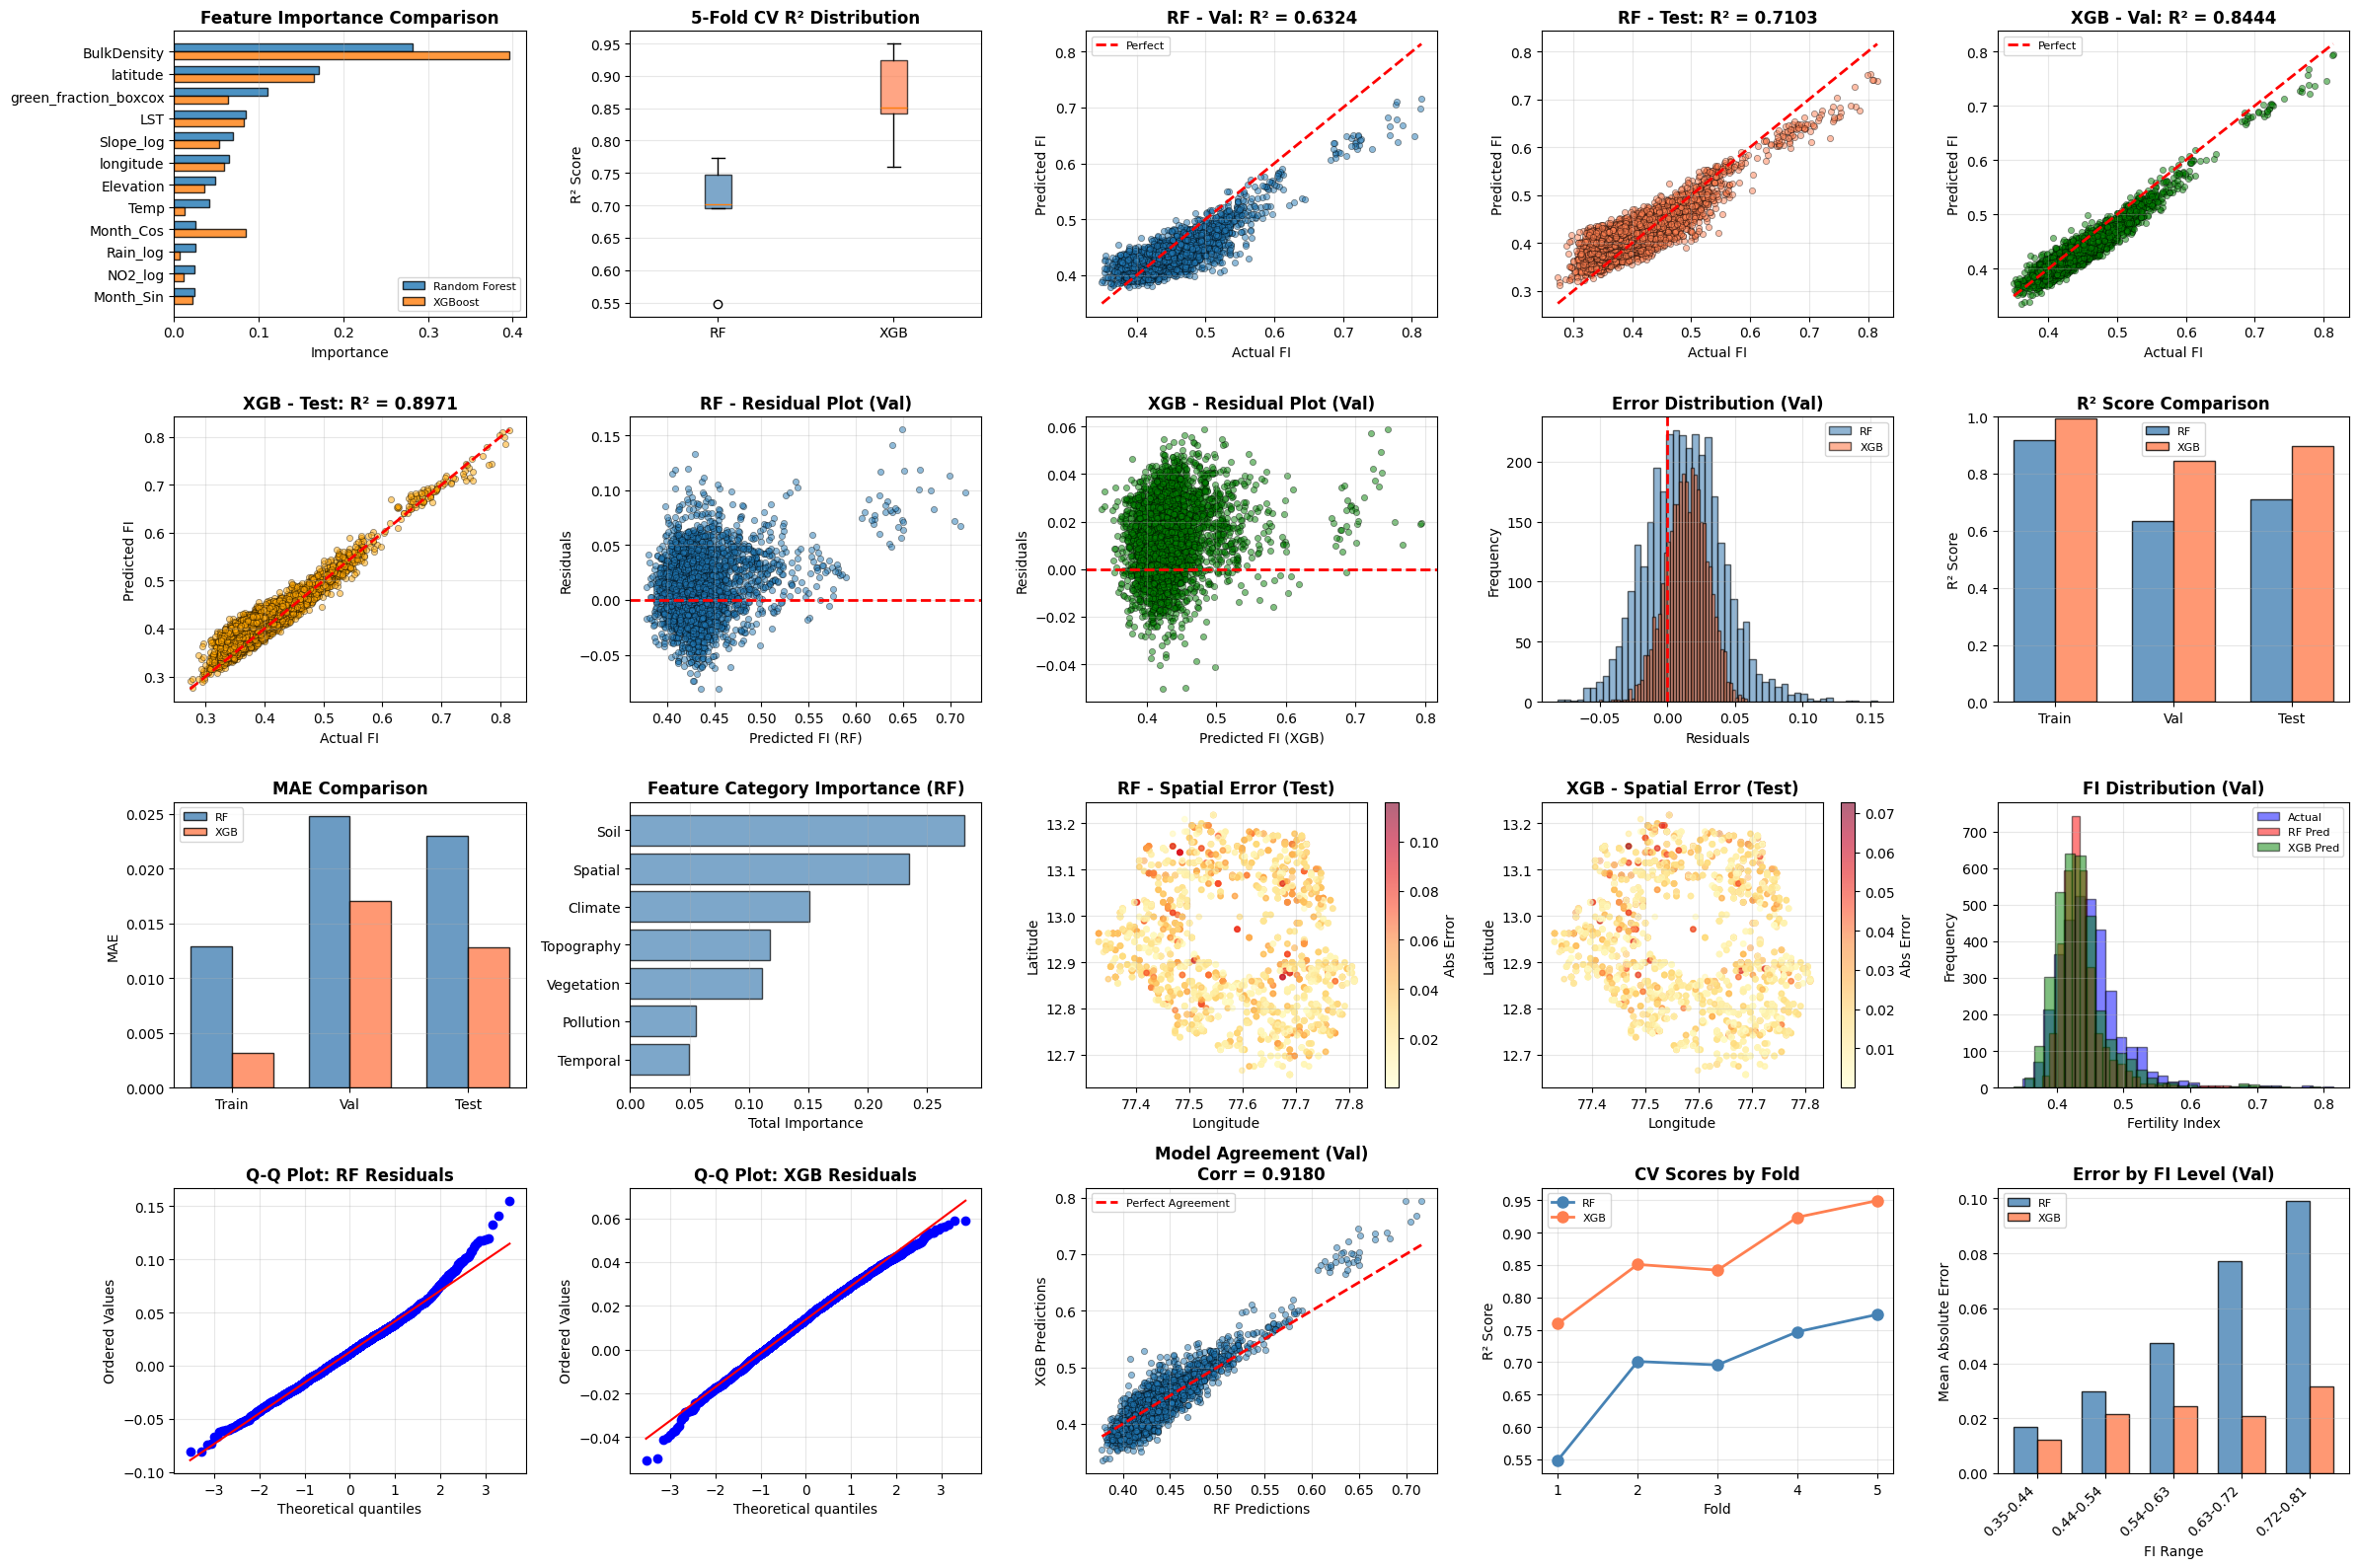

In [29]:
# ==============================================================================
# STEP 9: VISUALIZATIONS
# ==============================================================================
print("\n9. CREATING VISUALIZATIONS")
print("-" * 60)

if XGBOOST_AVAILABLE:
    fig = plt.figure(figsize=(24, 16))
    n_cols = 5
    n_rows = 4
else:
    fig = plt.figure(figsize=(20, 12))
    n_cols = 4
    n_rows = 3

plot_idx = 1

# 1. Feature Importance Comparison
ax1 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
top_n = 12
fi_top = feature_importance_df.head(top_n)
x = np.arange(top_n)
width = 0.35

plt.barh(x, fi_top['RF_Importance'], width, label='Random Forest', alpha=0.8, edgecolor='black')
if XGBOOST_AVAILABLE:
    plt.barh(x + width, fi_top['XGB_Importance'], width, label='XGBoost', alpha=0.8, edgecolor='black')
plt.yticks(x + width/2 if XGBOOST_AVAILABLE else x, fi_top['Feature'])
plt.xlabel('Importance', fontsize=10)
plt.title('Feature Importance Comparison', fontsize=12, fontweight='bold')
plt.legend(fontsize=8)
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')

# 2. Cross-Validation R² Scores
ax2 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
cv_data = [cv_scores_r2]
labels = ['RF']
if XGBOOST_AVAILABLE:
    cv_data.append(cv_scores_r2_xgb)
    labels.append('XGB')

bp = plt.boxplot(cv_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'coral'][:len(cv_data)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.ylabel('R² Score', fontsize=10)
plt.title('5-Fold CV R² Distribution', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3, axis='y')

# 3. RF: Predicted vs Actual (Validation)
ax3 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
plt.scatter(y_val, y_val_pred_rf, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
         'r--', linewidth=2, label='Perfect')
plt.xlabel('Actual FI', fontsize=10)
plt.ylabel('Predicted FI', fontsize=10)
plt.title(f'RF - Val: R² = {rf_metrics_val["R2"]:.4f}', fontsize=12, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 4. RF: Predicted vs Actual (Test)
ax4 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, s=20, color='coral', edgecolor='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel('Actual FI', fontsize=10)
plt.ylabel('Predicted FI', fontsize=10)
plt.title(f'RF - Test: R² = {rf_metrics_test["R2"]:.4f}', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

if XGBOOST_AVAILABLE:
    # 5. XGB: Predicted vs Actual (Validation)
    ax5 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    plt.scatter(y_val, y_val_pred_xgb, alpha=0.5, s=20, color='green', edgecolor='black', linewidth=0.5)
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
             'r--', linewidth=2, label='Perfect')
    plt.xlabel('Actual FI', fontsize=10)
    plt.ylabel('Predicted FI', fontsize=10)
    plt.title(f'XGB - Val: R² = {xgb_metrics_val["R2"]:.4f}', fontsize=12, fontweight='bold')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    
    # 6. XGB: Predicted vs Actual (Test)
    ax6 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    plt.scatter(y_test, y_test_pred_xgb, alpha=0.5, s=20, color='orange', edgecolor='black', linewidth=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2)
    plt.xlabel('Actual FI', fontsize=10)
    plt.ylabel('Predicted FI', fontsize=10)
    plt.title(f'XGB - Test: R² = {xgb_metrics_test["R2"]:.4f}', fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)

# 7. Residual Plot (RF)
ax7 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
residuals_rf = y_val - y_val_pred_rf
plt.scatter(y_val_pred_rf, residuals_rf, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted FI (RF)', fontsize=10)
plt.ylabel('Residuals', fontsize=10)
plt.title('RF - Residual Plot (Val)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

if XGBOOST_AVAILABLE:
    # 8. Residual Plot (XGB)
    ax8 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    residuals_xgb = y_val - y_val_pred_xgb
    plt.scatter(y_val_pred_xgb, residuals_xgb, alpha=0.5, s=20, color='green', edgecolor='black', linewidth=0.5)
    plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel('Predicted FI (XGB)', fontsize=10)
    plt.ylabel('Residuals', fontsize=10)
    plt.title('XGB - Residual Plot (Val)', fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)

# 9. Error Distribution Comparison
ax9 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
plt.hist(residuals_rf, bins=50, alpha=0.6, label='RF', edgecolor='black', color='steelblue')
if XGBOOST_AVAILABLE:
    plt.hist(residuals_xgb, bins=50, alpha=0.6, label='XGB', edgecolor='black', color='coral')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Residuals', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('Error Distribution (Val)', fontsize=12, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 10. R² Comparison
ax10 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
datasets = ['Train', 'Val', 'Test']
rf_r2_vals = [rf_metrics_train['R2'], rf_metrics_val['R2'], rf_metrics_test['R2']]
x = np.arange(len(datasets))
width = 0.35

plt.bar(x - width/2, rf_r2_vals, width, label='RF', alpha=0.8, edgecolor='black', color='steelblue')
if XGBOOST_AVAILABLE:
    xgb_r2_vals = [xgb_metrics_train['R2'], xgb_metrics_val['R2'], xgb_metrics_test['R2']]
    plt.bar(x + width/2, xgb_r2_vals, width, label='XGB', alpha=0.8, edgecolor='black', color='coral')
plt.ylabel('R² Score', fontsize=10)
plt.title('R² Score Comparison', fontsize=12, fontweight='bold')
plt.xticks(x, datasets)
plt.legend(fontsize=8)
plt.ylim(0, 1)
plt.grid(alpha=0.3, axis='y')

# 11. MAE Comparison
ax11 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
rf_mae_vals = [rf_metrics_train['MAE'], rf_metrics_val['MAE'], rf_metrics_test['MAE']]
plt.bar(x - width/2, rf_mae_vals, width, label='RF', alpha=0.8, edgecolor='black', color='steelblue')
if XGBOOST_AVAILABLE:
    xgb_mae_vals = [xgb_metrics_train['MAE'], xgb_metrics_val['MAE'], xgb_metrics_test['MAE']]
    plt.bar(x + width/2, xgb_mae_vals, width, label='XGB', alpha=0.8, edgecolor='black', color='coral')
plt.ylabel('MAE', fontsize=10)
plt.title('MAE Comparison', fontsize=12, fontweight='bold')
plt.xticks(x, datasets)
plt.legend(fontsize=8)
plt.grid(alpha=0.3, axis='y')

# 12. Feature Category Importance
ax12 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
feature_categories = {
    'Climate': ['Rain_log', 'Temp', 'LST'],
    'Vegetation': ['green_fraction_boxcox'],
    'Soil': ['BulkDensity'],
    'Topography': ['Elevation', 'Slope_log'],
    'Pollution': ['AOD_log', 'NO2_log', 'SO2'],
    'Temporal': ['Month_Sin', 'Month_Cos'],
    'Spatial': ['longitude', 'latitude']
}
cat_imp_rf = {}
for cat, feats in feature_categories.items():
    cat_imp_rf[cat] = feature_importance_df[feature_importance_df['Feature'].isin(feats)]['RF_Importance'].sum()

cat_df = pd.DataFrame(list(cat_imp_rf.items()), columns=['Category', 'Importance']).sort_values('Importance', ascending=False)
plt.barh(range(len(cat_df)), cat_df['Importance'], color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(cat_df)), cat_df['Category'])
plt.xlabel('Total Importance', fontsize=10)
plt.title('Feature Category Importance (RF)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')

# 13. Spatial Error Distribution (RF)
ax13 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
test_df = df_sorted.loc[test_mask].copy()
test_df['rf_pred'] = y_test_pred_rf
test_df['rf_error'] = np.abs(y_test - y_test_pred_rf)
sample_idx = np.random.choice(len(test_df), min(3000, len(test_df)), replace=False)
scatter = plt.scatter(test_df.iloc[sample_idx]['longitude'], 
                     test_df.iloc[sample_idx]['latitude'],
                     c=test_df.iloc[sample_idx]['rf_error'],
                     cmap='YlOrRd', alpha=0.6, s=15)
plt.xlabel('Longitude', fontsize=10)
plt.ylabel('Latitude', fontsize=10)
plt.title('RF - Spatial Error (Test)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Abs Error')
plt.grid(alpha=0.3)

if XGBOOST_AVAILABLE:
    # 14. Spatial Error Distribution (XGB)
    ax14 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    test_df['xgb_pred'] = y_test_pred_xgb
    test_df['xgb_error'] = np.abs(y_test - y_test_pred_xgb)
    scatter = plt.scatter(test_df.iloc[sample_idx]['longitude'], 
                         test_df.iloc[sample_idx]['latitude'],
                         c=test_df.iloc[sample_idx]['xgb_error'],
                         cmap='YlOrRd', alpha=0.6, s=15)
    plt.xlabel('Longitude', fontsize=10)
    plt.ylabel('Latitude', fontsize=10)
    plt.title('XGB - Spatial Error (Test)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, label='Abs Error')
    plt.grid(alpha=0.3)

# 15. FI Distribution: Actual vs Predicted
ax15 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
plt.hist(y_val, bins=30, alpha=0.5, label='Actual', edgecolor='black', color='blue')
plt.hist(y_val_pred_rf, bins=30, alpha=0.5, label='RF Pred', edgecolor='black', color='red')
if XGBOOST_AVAILABLE:
    plt.hist(y_val_pred_xgb, bins=30, alpha=0.5, label='XGB Pred', edgecolor='black', color='green')
plt.xlabel('Fertility Index', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('FI Distribution (Val)', fontsize=12, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 16. Q-Q Plot (RF)
ax16 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
stats.probplot(residuals_rf, dist="norm", plot=plt)
plt.title('Q-Q Plot: RF Residuals', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

if XGBOOST_AVAILABLE:
    # 17. Q-Q Plot (XGB)
    ax17 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    stats.probplot(residuals_xgb, dist="norm", plot=plt)
    plt.title('Q-Q Plot: XGB Residuals', fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)
    
    # 18. Prediction Agreement
    ax18 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    plt.scatter(y_val_pred_rf, y_val_pred_xgb, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
    plt.plot([y_val_pred_rf.min(), y_val_pred_rf.max()], 
             [y_val_pred_rf.min(), y_val_pred_rf.max()], 
             'r--', linewidth=2, label='Perfect Agreement')
    plt.xlabel('RF Predictions', fontsize=10)
    plt.ylabel('XGB Predictions', fontsize=10)
    corr_pred = np.corrcoef(y_val_pred_rf, y_val_pred_xgb)[0, 1]
    plt.title(f'Model Agreement (Val)\nCorr = {corr_pred:.4f}', fontsize=12, fontweight='bold')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    
    # 19. CV Score Comparison
    ax19 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    cv_comparison = pd.DataFrame({
        'Fold': list(range(1, 6)) * 2,
        'R² Score': list(cv_scores_r2) + list(cv_scores_r2_xgb),
        'Model': ['RF']*5 + ['XGB']*5
    })
    for model, color in zip(['RF', 'XGB'], ['steelblue', 'coral']):
        model_data = cv_comparison[cv_comparison['Model'] == model]
        plt.plot(model_data['Fold'], model_data['R² Score'], 
                marker='o', label=model, color=color, linewidth=2, markersize=8)
    plt.xlabel('Fold', fontsize=10)
    plt.ylabel('R² Score', fontsize=10)
    plt.title('CV Scores by Fold', fontsize=12, fontweight='bold')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    
    # 20. Error by FI Range
    ax20 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    fi_bins = pd.cut(y_val, bins=5)
    error_rf_by_bin = pd.DataFrame({'Bin': fi_bins, 'Error': np.abs(residuals_rf)}).groupby('Bin')['Error'].mean()
    error_xgb_by_bin = pd.DataFrame({'Bin': fi_bins, 'Error': np.abs(residuals_xgb)}).groupby('Bin')['Error'].mean()
    
    x_bins = np.arange(len(error_rf_by_bin))
    plt.bar(x_bins - width/2, error_rf_by_bin.values, width, label='RF', alpha=0.8, edgecolor='black', color='steelblue')
    plt.bar(x_bins + width/2, error_xgb_by_bin.values, width, label='XGB', alpha=0.8, edgecolor='black', color='coral')
    plt.xlabel('FI Range', fontsize=10)
    plt.ylabel('Mean Absolute Error', fontsize=10)
    plt.title('Error by FI Level (Val)', fontsize=12, fontweight='bold')
    plt.xticks(x_bins, [f'{b.left:.2f}-{b.right:.2f}' for b in error_rf_by_bin.index], rotation=45, ha='right')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Option2_Improved_Results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Option2_Improved_Results.png")

In [30]:
# ==============================================================================
# STEP 10: SAVE RESULTS
# ==============================================================================
print("\n10. SAVING RESULTS")
print("-" * 60)

# Save predictions
pd.DataFrame({'Actual': y_train, 'RF_Pred': y_train_pred_rf}).to_csv('Option2_Improved_predictions_train_rf.csv', index=False)
pd.DataFrame({'Actual': y_val, 'RF_Pred': y_val_pred_rf}).to_csv('Option2_Improved_predictions_val_rf.csv', index=False)
pd.DataFrame({'Actual': y_test, 'RF_Pred': y_test_pred_rf}).to_csv('Option2_Improved_predictions_test_rf.csv', index=False)

if XGBOOST_AVAILABLE:
    pd.DataFrame({'Actual': y_train, 'XGB_Pred': y_train_pred_xgb}).to_csv('Option2_Improved_predictions_train_xgb.csv', index=False)
    pd.DataFrame({'Actual': y_val, 'XGB_Pred': y_val_pred_xgb}).to_csv('Option2_Improved_predictions_val_xgb.csv', index=False)
    pd.DataFrame({'Actual': y_test, 'XGB_Pred': y_test_pred_xgb}).to_csv('Option2_Improved_predictions_test_xgb.csv', index=False)

# Save metrics
metrics_summary = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'RF_MAE': [rf_metrics_train['MAE'], rf_metrics_val['MAE'], rf_metrics_test['MAE']],
    'RF_RMSE': [rf_metrics_train['RMSE'], rf_metrics_val['RMSE'], rf_metrics_test['RMSE']],
    'RF_R2': [rf_metrics_train['R2'], rf_metrics_val['R2'], rf_metrics_test['R2']]
})

if XGBOOST_AVAILABLE:
    metrics_summary['XGB_MAE'] = [xgb_metrics_train['MAE'], xgb_metrics_val['MAE'], xgb_metrics_test['MAE']]
    metrics_summary['XGB_RMSE'] = [xgb_metrics_train['RMSE'], xgb_metrics_val['RMSE'], xgb_metrics_test['RMSE']]
    metrics_summary['XGB_R2'] = [xgb_metrics_train['R2'], xgb_metrics_val['R2'], xgb_metrics_test['R2']]

metrics_summary.to_csv('Option2_Improved_metrics_summary.csv', index=False)

# Save CV results
cv_results = pd.DataFrame({
    'Fold': range(1, 6),
    'RF_R2': cv_scores_r2,
    'RF_MAE': cv_scores_mae,
    'RF_RMSE': cv_scores_rmse
})

if XGBOOST_AVAILABLE:
    cv_results['XGB_R2'] = cv_scores_r2_xgb
    cv_results['XGB_MAE'] = cv_scores_mae_xgb
    cv_results['XGB_RMSE'] = cv_scores_rmse_xgb

cv_results.to_csv('Option2_Improved_cv_results.csv', index=False)

# Save feature importance
feature_importance_df.to_csv('Option2_Improved_feature_importance.csv', index=False)

# Save target variables
pd.DataFrame({'FertilityIndex': y_train}).to_csv('Option2_Improved_y_train.csv', index=False)
pd.DataFrame({'FertilityIndex': y_val}).to_csv('Option2_Improved_y_val.csv', index=False)
pd.DataFrame({'FertilityIndex': y_test}).to_csv('Option2_Improved_y_test.csv', index=False)

print("✓ Saved all results:")
print("  - Option2_Improved_predictions_*_rf.csv")
if XGBOOST_AVAILABLE:
    print("  - Option2_Improved_predictions_*_xgb.csv")
print("  - Option2_Improved_metrics_summary.csv")
print("  - Option2_Improved_cv_results.csv")
print("  - Option2_Improved_feature_importance.csv")
print("  - Option2_Improved_y_*.csv")
print("  - Option2_Improved_Results.png")


10. SAVING RESULTS
------------------------------------------------------------
✓ Saved all results:
  - Option2_Improved_predictions_*_rf.csv
  - Option2_Improved_predictions_*_xgb.csv
  - Option2_Improved_metrics_summary.csv
  - Option2_Improved_cv_results.csv
  - Option2_Improved_feature_importance.csv
  - Option2_Improved_y_*.csv
  - Option2_Improved_Results.png


In [31]:
# ==============================================================================
# STEP 11: FINAL SUMMARY
# ==============================================================================
print("\n" + "="*80)
print("✅ OPTION 2 IMPROVED: REGRESSION ONLY + XGBOOST + CV - COMPLETE")
print("="*80)

print(f"\n📊 CROSS-VALIDATION RESULTS (TimeSeriesSplit - 5 Splits):")
print(f"\nRandom Forest:")
print(f"  Mean R²:   {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
print(f"  Mean MAE:  {cv_scores_mae.mean():.4f} ± {cv_scores_mae.std():.4f}")
print(f"  Mean RMSE: {cv_scores_rmse.mean():.4f} ± {cv_scores_rmse.std():.4f}")

if XGBOOST_AVAILABLE:
    print(f"\nXGBoost:")
    print(f"  Mean R²:   {cv_scores_r2_xgb.mean():.4f} ± {cv_scores_r2_xgb.std():.4f}")
    print(f"  Mean MAE:  {cv_scores_mae_xgb.mean():.4f} ± {cv_scores_mae_xgb.std():.4f}")
    print(f"  Mean RMSE: {cv_scores_rmse_xgb.mean():.4f} ± {cv_scores_rmse_xgb.std():.4f}")

print(f"\n📊 VALIDATION SET RESULTS:")
print(f"\nRandom Forest:")
print(f"  MAE:  {rf_metrics_val['MAE']:.4f}")
print(f"  RMSE: {rf_metrics_val['RMSE']:.4f}")
print(f"  R²:   {rf_metrics_val['R2']:.4f}")

if XGBOOST_AVAILABLE:
    print(f"\nXGBoost:")
    print(f"  MAE:  {xgb_metrics_val['MAE']:.4f}")
    print(f"  RMSE: {xgb_metrics_val['RMSE']:.4f}")
    print(f"  R²:   {xgb_metrics_val['R2']:.4f}")

print(f"\n📊 TEST SET RESULTS:")
print(f"\nRandom Forest:")
print(f"  MAE:  {rf_metrics_test['MAE']:.4f}")
print(f"  RMSE: {rf_metrics_test['RMSE']:.4f}")
print(f"  R²:   {rf_metrics_test['R2']:.4f}")

if XGBOOST_AVAILABLE:
    print(f"\nXGBoost:")
    print(f"  MAE:  {xgb_metrics_test['MAE']:.4f}")
    print(f"  RMSE: {xgb_metrics_test['RMSE']:.4f}")
    print(f"  R²:   {xgb_metrics_test['R2']:.4f}")

print(f"\n🏆 BEST MODEL: {best_model}")

print(f"\n🔑 KEY IMPROVEMENTS:")
print(f"  ✓ Removed classification (class imbalance issue fixed)")
print(f"  ✓ Added TimeSeriesSplit CV (respects temporal order)")
if XGBOOST_AVAILABLE:
    print(f"  ✓ Compared RF vs XGBoost (side-by-side)")
print(f"  ✓ Comprehensive visualizations ({plot_idx-1} plots)")

print(f"\n🎯 INTERPRETATION:")
if rf_metrics_val['R2'] > 0.6 or (XGBOOST_AVAILABLE and xgb_metrics_val['R2'] > 0.6):
    print(f"  ✅ EXCELLENT: R² > 0.6 on validation (indirect prediction)")
    print(f"     Environmental factors strongly predict fertility!")
elif rf_metrics_val['R2'] > 0.4 or (XGBOOST_AVAILABLE and xgb_metrics_val['R2'] > 0.4):
    print(f"  ✓ GOOD: R² > 0.4 - Model captures environmental effects")
else:
    print(f"  ⚠️  MODERATE: Consider adding more environmental features")

print("\n" + "="*80)


✅ OPTION 2 IMPROVED: REGRESSION ONLY + XGBOOST + CV - COMPLETE

📊 CROSS-VALIDATION RESULTS (TimeSeriesSplit - 5 Splits):

Random Forest:
  Mean R²:   0.6932 ± 0.0778
  Mean MAE:  0.0238 ± 0.0027
  Mean RMSE: 0.0307 ± 0.0042

XGBoost:
  Mean R²:   0.8650 ± 0.0670
  Mean MAE:  0.0160 ± 0.0043
  Mean RMSE: 0.0199 ± 0.0055

📊 VALIDATION SET RESULTS:

Random Forest:
  MAE:  0.0248
  RMSE: 0.0316
  R²:   0.6324

XGBoost:
  MAE:  0.0170
  RMSE: 0.0206
  R²:   0.8444

📊 TEST SET RESULTS:

Random Forest:
  MAE:  0.0230
  RMSE: 0.0296
  R²:   0.7103

XGBoost:
  MAE:  0.0128
  RMSE: 0.0176
  R²:   0.8971

🏆 BEST MODEL: XGBoost

🔑 KEY IMPROVEMENTS:
  ✓ Removed classification (class imbalance issue fixed)
  ✓ Added TimeSeriesSplit CV (respects temporal order)
  ✓ Compared RF vs XGBoost (side-by-side)
  ✓ Comprehensive visualizations (20 plots)

🎯 INTERPRETATION:
  ✅ EXCELLENT: R² > 0.6 on validation (indirect prediction)
     Environmental factors strongly predict fertility!

